# ADNI: Final Discordance-Centered External Reliability Analysis

This notebook is **standalone**. It does not require the original ADNI modeling notebook to be open and does not require variables to exist in the active kernel.

It reuses:
- the saved subject-disjoint `outer_repeats/test.csv` and `oof.csv` artifacts,
- the completed 1488-D Triad embedding cache,
- the saved ADNI prediction cohort.

## Central construct

The primary discordance is **current-visit state discordance**:

\[
D_{state}=|Z_{brain}-Z_{cognition}|
\]

The brain index is an age-prediction deviation from the frozen Triad representation. The cognition index is age/sex-adjusted MMSE impairment. The two indices are never trained toward the same future target.

The notebook evaluates:
1. state discordance -> future forecast error,
2. discordance-stratified failure detection,
3. leakage-controlled selective prediction,
4. discordance-aware routing/abstention,
5. signed directional discordance,
6. temporal change in discordance,
7. state vs forecast discordance,
8. residualized forecast discordance,
9. matched subject-level MRI permutation negative control,
10. locked OASIS -> ADNI state-discordance transfer,
11. an ADNI sample-expansion audit using already-verified embeddings.

No DICOM rescan or Triad re-extraction is performed.

In [39]:
import gc, json, math, random, warnings, re, os, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, pearsonr

from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, LinearRegression, LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, average_precision_score
)
import joblib

warnings.filterwarnings("ignore")
SEED = 42
rng_global = np.random.default_rng(SEED)
random.seed(SEED)
np.random.seed(SEED)

def safe_spearman(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if len(x) < 10 or np.unique(x).size < 3 or np.unique(y).size < 3:
        return np.nan, np.nan
    r, p = spearmanr(x, y)
    return float(r), float(p)

def bootstrap_rho(df, x, y, n_boot=2000, seed=42):
    d = df[[x, y, "subject_id"]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    d = d.groupby("subject_id", as_index=False)[[x, y]].mean()
    if len(d) < 10:
        return {"N_subjects": int(len(d)), "rho": np.nan, "ci_low": np.nan, "ci_high": np.nan}
    r, _ = safe_spearman(d[x], d[y])
    rng = np.random.default_rng(seed)
    vals = []
    subs = d.index.to_numpy()
    for _ in range(n_boot):
        idx = rng.choice(subs, size=len(subs), replace=True)
        b = d.loc[idx]
        rr, _ = safe_spearman(b[x], b[y])
        if np.isfinite(rr):
            vals.append(rr)
    q = np.quantile(vals, [0.025, 0.975]) if vals else [np.nan, np.nan]
    return {"N_subjects": int(len(d)), "rho": r, "ci_low": float(q[0]), "ci_high": float(q[1])}

def risk_curve(df, score, error="abs_error", coverages=None):
    if coverages is None:
        coverages = np.array([.2,.3,.4,.5,.6,.7,.8,.9,1.0])
    d = df[[score, error]].replace([np.inf,-np.inf],np.nan).dropna().sort_values(score).reset_index(drop=True)
    rows=[]
    if d.empty:
        return pd.DataFrame()
    for c in coverages:
        n=max(1,int(round(c*len(d))))
        rows.append({"score":score,"coverage":n/len(d),"N":n,"MAE":float(d.iloc[:n][error].mean())})
    return pd.DataFrame(rows)

def aurc(rc):
    if rc.empty: return np.nan
    z=rc.sort_values("coverage")
    return float(np.trapezoid(z["MAE"], z["coverage"]))

def top_fraction_enrichment(df, score, event_col, frac=0.20):
    d=df[[score,event_col]].replace([np.inf,-np.inf],np.nan).dropna().copy()
    if len(d)<10 or d[event_col].sum()==0:
        return {"N":len(d),"top_N":0,"event_total":int(d[event_col].sum()),"event_top":np.nan,"capture":np.nan,"enrichment":np.nan}
    n=max(1,int(round(frac*len(d))))
    top=d.sort_values(score,ascending=False).head(n)
    total=d[event_col].sum()
    ev=top[event_col].sum()
    base=total/len(d)
    return {"N":len(d),"top_N":n,"event_total":int(total),"event_top":int(ev),
            "capture":float(ev/total),"enrichment":float((ev/n)/base) if base>0 else np.nan}

def quantile_threshold(dev, col, q=.75):
    x=pd.to_numeric(dev[col],errors="coerce").replace([np.inf,-np.inf],np.nan).dropna()
    return float(x.quantile(q)) if len(x) else np.nan

def infer_date_col(df):
    for c in ["clinical_date","clinical_day","anchor_clinical_date","date","visit_date"]:
        if c in df.columns: return c
    return None

In [40]:
def resolve_embedding_path(x):
    p = Path(str(x))

    # Already absolute
    if p.is_absolute():
        return p

    # Try the stored relative path directly
    p1 = EMBED_ROOT / p
    if p1.exists():
        return p1

    # Fallback: filename directly under embedding root
    p2 = EMBED_ROOT / p.name
    if p2.exists():
        return p2

    return p1

emb_manifest["embedding_path"] = (
    emb_manifest["embedding_path"]
    .map(resolve_embedding_path)
)

In [41]:
# ============================================================
# ROBUST ADNI DATE PARSER
# ============================================================

def parse_adni_date(x):

    if x is None or pd.isna(x):
        return pd.NaT

    # Already datetime-like
    if isinstance(x, (pd.Timestamp, np.datetime64)):
        return pd.to_datetime(
            x,
            errors="coerce"
        )

    s = str(x).strip()

    if not s:
        return pd.NaT

    # Handle numeric/string YYYYMMDD,
    # e.g. 20060418 or 20060418.0
    digits = re.sub(
        r"\.0+$",
        "",
        s
    )

    if re.fullmatch(
        r"\d{8}",
        digits
    ):
        dt = pd.to_datetime(
            digits,
            format="%Y%m%d",
            errors="coerce"
        )

        if pd.notna(dt):
            return dt

    # Standard date strings
    return pd.to_datetime(
        s,
        errors="coerce"
    )

In [42]:
# ============================================================
# 1. LOAD SAVED ADNI OUTER-REPEAT ARTIFACTS + CURRENT-VISIT DATA
# ============================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd

ADNI_ROOT = Path(r"C:\Projects\OASIS\ADNI")

PAPER_ROOT = (
    ADNI_ROOT
    / "PAPER_READY_FINAL_RESULTS"
)

REPEAT_ROOT = (
    PAPER_ROOT
    / "outer_repeats"
)

EMBED_ROOT = (
    ADNI_ROOT
    / "prep"
    / "triad_embeddings"
)

CLINICAL_ROOT = (
    ADNI_ROOT
    / "prep"
    / "clinical"
)

OUT_ROOT = (
    PAPER_ROOT
    / "DISCORDANCE_FINAL_ANALYSIS"
)

OUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# HELPER: NORMALIZE ADNI SUBJECT IDS
# ============================================================

def normalize_adni_subject(x):

    if pd.isna(x):
        return np.nan

    s = str(x).upper().strip()

    m = re.search(
        r"(\d{3}_S_\d{4})",
        s
    )

    if m:
        return m.group(1)

    return np.nan


# ============================================================
# HELPER: ROBUST ADNI DATE PARSER
# ============================================================

def parse_adni_date(x):

    if x is None:
        return pd.NaT

    if isinstance(
        x,
        (
            pd.Timestamp,
            np.datetime64,
        )
    ):
        return pd.to_datetime(
            x,
            errors="coerce"
        )

    try:
        import datetime as dt

        if isinstance(
            x,
            (
                dt.datetime,
                dt.date,
            )
        ):
            return pd.Timestamp(x)

    except Exception:
        pass

    if pd.isna(x):
        return pd.NaT

    s = str(x).strip()

    if not s:
        return pd.NaT

    # --------------------------------------------------------
    # ADNI numeric date:
    # 20060418
    # 20060418.0
    # --------------------------------------------------------

    s2 = re.sub(
        r"\.0+$",
        "",
        s
    )

    if re.fullmatch(
        r"\d{8}",
        s2
    ):

        return pd.to_datetime(
            s2,
            format="%Y%m%d",
            errors="coerce"
        )

    # --------------------------------------------------------
    # Standard date string
    # --------------------------------------------------------

    return pd.to_datetime(
        s,
        errors="coerce"
    )


# ============================================================
# HELPER: COLUMN DISCOVERY
# ============================================================

def find_column(
    df,
    candidates
):

    for c in candidates:

        if c in df.columns:
            return c

    return None


# ============================================================
# 1A. LOAD OUTER-REPEAT ARTIFACTS
# ============================================================

def load_repeats(root):

    test_parts = []
    oof_parts = []

    repeat_dirs = sorted(
        root.glob("repeat_*")
    )

    if not repeat_dirs:

        raise FileNotFoundError(
            f"No repeat_* directories found:\n{root}"
        )

    for d in repeat_dirs:

        rep = int(
            d.name.split("_")[-1]
        )

        test_file = d / "test.csv"
        oof_file = d / "oof.csv"

        if not test_file.exists():

            raise FileNotFoundError(
                f"Missing:\n{test_file}"
            )

        if not oof_file.exists():

            raise FileNotFoundError(
                f"Missing:\n{oof_file}"
            )

        t = pd.read_csv(
            test_file,
            low_memory=False
        )

        o = pd.read_csv(
            oof_file,
            low_memory=False
        )

        t["repeat"] = rep
        o["repeat"] = rep

        test_parts.append(t)
        oof_parts.append(o)

    return (
        pd.concat(
            test_parts,
            ignore_index=True
        ),
        pd.concat(
            oof_parts,
            ignore_index=True
        )
    )


test_all, oof_all = load_repeats(
    REPEAT_ROOT
)


test_all["subject_id"] = (
    test_all["subject_id"]
    .apply(normalize_adni_subject)
)

oof_all["subject_id"] = (
    oof_all["subject_id"]
    .apply(normalize_adni_subject)
)


print("=" * 80)
print("ADNI SAVED ARTIFACTS")
print("=" * 80)

print(
    "Held-out rows:",
    len(test_all)
)

print(
    "OOF rows:",
    len(oof_all)
)

print(
    "Held-out subjects:",
    test_all["subject_id"].nunique()
)

print(
    "OOF subjects:",
    oof_all["subject_id"].nunique()
)

print(
    "Repeats:",
    sorted(
        test_all["repeat"].unique()
    )
)


# ============================================================
# 1B. LOAD SAVED PREDICTION COHORT
# ============================================================

cohort_candidates = [

    PAPER_ROOT
    / "prediction_cohort.csv",

    CLINICAL_ROOT
    / "adni_prediction_cohort_pre_pipeline.csv",
]

cohort_file = next(
    (
        p
        for p in cohort_candidates
        if p.exists()
    ),
    None
)

if cohort_file is None:

    raise FileNotFoundError(
        "Could not find the saved ADNI "
        "prediction cohort.\n\n"
        + "\n".join(
            str(p)
            for p in cohort_candidates
        )
    )


cohort = pd.read_csv(
    cohort_file,
    low_memory=False
)

print(
    "\nPrediction cohort:",
    cohort_file
)

print(
    "Rows:",
    len(cohort)
)


# ============================================================
# 1C. NORMALIZE COHORT SUBJECT IDS
# ============================================================

if "subject_id" not in cohort.columns:

    ptid_col = find_column(
        cohort,
        [
            "PTID",
            "RID",
            "Subject ID",
        ]
    )

    if ptid_col is None:

        raise KeyError(
            "Could not identify subject ID "
            "column in prediction cohort."
        )

    cohort["subject_id"] = (
        cohort[ptid_col]
        .apply(normalize_adni_subject)
    )

else:

    cohort["subject_id"] = (
        cohort["subject_id"]
        .apply(normalize_adni_subject)
    )


# ============================================================
# 1D. IDENTIFY MMSE + DATE
# ============================================================

mmse_col = find_column(
    cohort,
    [
        "anchor_mmse",
        "MMSE",
        "mmse",
    ]
)

date_col = find_column(
    cohort,
    [
        "anchor_clinical_date",
        "clinical_date",
        "visit_date",
        "date",
    ]
)

if mmse_col is None:

    raise KeyError(
        "Could not find anchor MMSE "
        "in prediction_cohort.csv."
    )

if date_col is None:

    raise KeyError(
        "Could not find anchor clinical date "
        "in prediction_cohort.csv."
    )


# ============================================================
# 1E. STANDARDIZE MMSE + DATE
# ============================================================

cohort["anchor_mmse"] = pd.to_numeric(
    cohort[mmse_col],
    errors="coerce"
)

cohort["anchor_clinical_date"] = (
    cohort[date_col]
    .apply(parse_adni_date)
)


# ============================================================
# 1F. RECOVER ANCHOR AGE
# ============================================================

age_col = find_column(
    cohort,
    [
        "anchor_age",
        "age_visit",
        "age",
        "AGE",
    ]
)


if age_col is not None:

    # Age already exists in prediction cohort.
    cohort["anchor_age"] = pd.to_numeric(
        cohort[age_col],
        errors="coerce"
    )

    print(
        "Anchor age source: prediction cohort"
    )


else:

    # --------------------------------------------------------
    # Recover age from the original clinical table.
    # --------------------------------------------------------

    clinical_file = (
        CLINICAL_ROOT
        / "adni_clinical_longitudinal_core.csv"
    )

    if not clinical_file.exists():

        matches = list(
            ADNI_ROOT.rglob(
                "*clinical*longitudinal*.csv"
            )
        )

        if matches:
            clinical_file = matches[0]

    if not clinical_file.exists():

        raise FileNotFoundError(
            "Could not find ADNI clinical "
            "longitudinal core needed to recover age."
        )

    print(
        "Recovering age from:",
        clinical_file
    )

    clinical_source = pd.read_csv(
        clinical_file,
        low_memory=False
    )


    # --------------------------------------------------------
    # Subject ID
    # --------------------------------------------------------

    source_subject_col = find_column(
        clinical_source,
        [
            "subject_id",
            "PTID",
            "Subject ID",
            "RID",
        ]
    )

    if source_subject_col is None:

        raise KeyError(
            "Could not identify subject ID "
            "in clinical longitudinal core."
        )

    clinical_source["subject_id"] = (
        clinical_source[
            source_subject_col
        ]
        .apply(normalize_adni_subject)
    )


    # --------------------------------------------------------
    # Clinical date
    # --------------------------------------------------------

    source_date_col = find_column(
        clinical_source,
        [
            "clinical_date",
            "VISDATE",
            "visit_date",
            "Visit Date",
            "DATE",
        ]
    )

    if source_date_col is None:

        raise KeyError(
            "Could not identify clinical date "
            "in clinical longitudinal core."
        )

    clinical_source[
        "anchor_clinical_date"
    ] = (
        clinical_source[
            source_date_col
        ]
        .apply(parse_adni_date)
    )


    # --------------------------------------------------------
    # Age
    # --------------------------------------------------------

    source_age_col = find_column(
        clinical_source,
        [
            "age_visit",
            "AGE",
            "age",
            "Age",
        ]
    )

    if source_age_col is None:

        raise KeyError(
            "Could not identify age_visit "
            "in clinical longitudinal core."
        )

    clinical_source[
        "anchor_age"
    ] = pd.to_numeric(
        clinical_source[
            source_age_col
        ],
        errors="coerce"
    )


    # --------------------------------------------------------
    # Clean lookup table
    # --------------------------------------------------------

    age_lookup = (
        clinical_source[
            [
                "subject_id",
                "anchor_clinical_date",
                "anchor_age",
            ]
        ]
        .dropna(
            subset=[
                "subject_id",
                "anchor_clinical_date",
            ]
        )
        .drop_duplicates(
            [
                "subject_id",
                "anchor_clinical_date",
            ],
            keep="last"
        )
    )


    # --------------------------------------------------------
    # Merge age into prediction cohort
    # --------------------------------------------------------

    cohort = cohort.merge(
        age_lookup,
        on=[
            "subject_id",
            "anchor_clinical_date",
        ],
        how="left",
        suffixes=(
            "",
            "_recovered"
        )
    )


    # If there was already an empty/partial anchor_age,
    # combine it with the recovered value.
    if "anchor_age_recovered" in cohort.columns:

        if "anchor_age" in cohort.columns:

            cohort["anchor_age"] = (
                pd.to_numeric(
                    cohort["anchor_age"],
                    errors="coerce"
                )
                .combine_first(
                    pd.to_numeric(
                        cohort[
                            "anchor_age_recovered"
                        ],
                        errors="coerce"
                    )
                )
            )

        else:

            cohort["anchor_age"] = (
                pd.to_numeric(
                    cohort[
                        "anchor_age_recovered"
                    ],
                    errors="coerce"
                )
            )

        cohort = cohort.drop(
            columns=[
                "anchor_age_recovered"
            ],
            errors="ignore"
        )


# ============================================================
# 1G. SEX
# ============================================================

sex_col = find_column(
    cohort,
    [
        "sex",
        "Sex",
        "SEX",
        "PTGENDER",
        "gender",
        "Gender",
    ]
)


if sex_col is not None:

    cohort["sex"] = (
        cohort[sex_col]
        .fillna("UNK")
        .astype(str)
    )


else:

    ptdemog_candidates = sorted(
        ADNI_ROOT.rglob(
            "*PTDEMOG*.csv"
        )
    )

    sexmap = None

    if ptdemog_candidates:

        demog_file = (
            ptdemog_candidates[0]
        )

        dd = pd.read_csv(
            demog_file,
            low_memory=False
        )

        demog_subject_col = find_column(
            dd,
            [
                "PTID",
                "subject_id",
            ]
        )

        demog_sex_col = find_column(
            dd,
            [
                "PTGENDER",
                "SEX",
                "sex",
            ]
        )

        if (
            demog_subject_col is not None
            and demog_sex_col is not None
        ):

            sexmap = pd.DataFrame(
                {
                    "subject_id":
                        dd[
                            demog_subject_col
                        ]
                        .apply(
                            normalize_adni_subject
                        ),

                    "sex":
                        dd[
                            demog_sex_col
                        ]
                        .astype(str),
                }
            )

            sexmap = (
                sexmap
                .dropna(
                    subset=[
                        "subject_id"
                    ]
                )
                .drop_duplicates(
                    "subject_id"
                )
            )

    if sexmap is not None:

        cohort = cohort.merge(
            sexmap,
            on="subject_id",
            how="left"
        )

    else:

        cohort["sex"] = "UNK"


cohort["sex"] = (
    cohort["sex"]
    .fillna("UNK")
    .astype(str)
)


# ============================================================
# 1H. FINAL ANCHOR METADATA QC
# ============================================================

print(
    "\n" + "=" * 80
)

print(
    "ADNI ANCHOR METADATA QC"
)

print(
    "=" * 80
)

print(
    "Rows:",
    len(cohort)
)

print(
    "Anchor MMSE:",
    int(
        cohort[
            "anchor_mmse"
        ].notna().sum()
    )
)

print(
    "Anchor age:",
    int(
        cohort[
            "anchor_age"
        ].notna().sum()
    )
)

print(
    "Clinical date:",
    int(
        cohort[
            "anchor_clinical_date"
        ].notna().sum()
    )
)

print(
    "Sex:",
    int(
        cohort[
            "sex"
        ].notna().sum()
    )
)


# ============================================================
# 1I. TRIAD EMBEDDING MANIFEST
# ============================================================

EMBED_MANIFEST = (
    EMBED_ROOT
    / "embedding_manifest.csv"
)

if not EMBED_MANIFEST.exists():

    raise FileNotFoundError(
        f"Missing embedding manifest:\n"
        f"{EMBED_MANIFEST}"
    )


emb_manifest = pd.read_csv(
    EMBED_MANIFEST,
    low_memory=False
)


emb_manifest["subject_id"] = (
    emb_manifest["subject_id"]
    .apply(normalize_adni_subject)
)


# ADNI uses calendar dates.
for col in [
    "mri_date",
    "acquisition_date",
    "visit_date",
    "study_date",
]:

    if col in emb_manifest.columns:

        emb_manifest[col] = (
            emb_manifest[col]
            .apply(parse_adni_date)
        )


emb_manifest = emb_manifest[
    emb_manifest["status"].eq("OK")
    &
    emb_manifest["embedding_dim"].eq(
        1488
    )
].copy()


# ============================================================
# 1J. ROBUST EMBEDDING PATH RESOLUTION
# ============================================================

def resolve_embedding_path(x):

    if pd.isna(x):
        return None

    p = Path(
        str(x)
    )

    if (
        p.is_absolute()
        and p.exists()
    ):
        return p

    p1 = EMBED_ROOT / p

    if p1.exists():
        return p1

    p2 = EMBED_ROOT / p.name

    if p2.exists():
        return p2

    return None


emb_manifest[
    "embedding_path"
] = (
    emb_manifest[
        "embedding_path"
    ]
    .map(
        resolve_embedding_path
    )
)


# ============================================================
# 1K. ATTACH CURRENT MRI EMBEDDING
# ============================================================

def attach_current_embedding(
    frame
):

    d = frame.copy()

    frame_date_col = find_column(
        d,
        [
            "anchor_clinical_date",
            "clinical_date",
            "visit_date",
            "date",
        ]
    )

    if frame_date_col is None:

        raise KeyError(
            "Saved ADNI test/OOF artifact "
            "has no clinical date field."
        )

    d[
        "_clinical_date_for_match"
    ] = (
        d[frame_date_col]
        .apply(parse_adni_date)
    )

    lookup = {
        sid: g.sort_values(
            "mri_date"
        )
        for sid, g
        in emb_manifest.groupby(
            "subject_id"
        )
    }

    paths = []
    gaps = []

    for _, row in d.iterrows():

        sid = row[
            "subject_id"
        ]

        cdate = row[
            "_clinical_date_for_match"
        ]

        g = lookup.get(
            sid
        )

        if (
            g is None
            or pd.isna(cdate)
        ):

            paths.append(None)
            gaps.append(np.nan)
            continue

        prior = g[
            g["mri_date"] <= cdate
        ].copy()

        if prior.empty:

            paths.append(None)
            gaps.append(np.nan)
            continue

        prior["gap_days"] = (
            cdate
            - prior["mri_date"]
        ).dt.days

        prior = prior[
            prior["gap_days"] >= 0
        ]

        prior = prior[
            prior["gap_days"] <= 180
        ]

        if prior.empty:

            paths.append(None)
            gaps.append(np.nan)
            continue

        j = (
            prior["gap_days"]
            .abs()
            .idxmin()
        )

        selected = prior.loc[j]

        paths.append(
            selected[
                "embedding_path"
            ]
        )

        gaps.append(
            float(
                selected[
                    "gap_days"
                ]
            )
        )

    d[
        "embedding_path"
    ] = paths

    d[
        "mri_gap_days"
    ] = gaps

    d = d.drop(
        columns=[
            "_clinical_date_for_match"
        ],
        errors="ignore"
    )

    return d


test_meta = attach_current_embedding(
    test_all
)

oof_meta = attach_current_embedding(
    oof_all
)


# ============================================================
# 1L. LOAD EMBEDDING CACHE
# ============================================================

def load_embedding_cache(
    df
):

    X = np.full(
        (
            len(df),
            1488
        ),
        np.nan,
        dtype=np.float32
    )

    cache = {}

    for i, p in enumerate(
        df["embedding_path"]
    ):

        if p is None:
            continue

        if pd.isna(p):
            continue

        p = Path(
            str(p)
        )

        if not p.exists():
            continue

        key = str(
            p.resolve()
        )

        if key not in cache:

            try:

                z = np.asarray(
                    np.load(
                        p,
                        mmap_mode="r"
                    ),
                    dtype=np.float32
                )

                if (
                    z.ndim == 1
                    and len(z) == 1488
                    and np.isfinite(z).all()
                ):

                    cache[key] = z.copy()

                else:

                    cache[key] = None

            except Exception:

                cache[key] = None

        if cache[key] is not None:

            X[i] = cache[key]

    return X


test_X = load_embedding_cache(
    test_meta
)

oof_X = load_embedding_cache(
    oof_meta
)


# ============================================================
# 1M. FINAL STATE-DISCORDANCE INPUT QC
# ============================================================

print(
    "\n" + "=" * 80
)

print(
    "ADNI STATE-DISCORDANCE INPUT QC"
)

print(
    "=" * 80
)

for name, df, X in [
    (
        "OOF",
        oof_meta,
        oof_X
    ),
    (
        "TEST",
        test_meta,
        test_X
    ),
]:

    emb_ok = np.isfinite(
        X
    ).all(
        axis=1
    )

    age_ok = (
        pd.to_numeric(
            df["anchor_age"],
            errors="coerce"
        )
        .notna()
    )

    mmse_ok = (
        pd.to_numeric(
            df["anchor_mmse"],
            errors="coerce"
        )
        .notna()
    )

    complete = (
        emb_ok
        &
        age_ok.to_numpy()
        &
        mmse_ok.to_numpy()
    )

    print(
        f"{name}: "
        f"rows={len(df)} | "
        f"embeddings={int(emb_ok.sum())} | "
        f"age={int(age_ok.sum())} | "
        f"MMSE={int(mmse_ok.sum())} | "
        f"COMPLETE={int(complete.sum())}"
    )


# ============================================================
# HARD FAILS
# ============================================================

if len(test_meta) == 0:

    raise RuntimeError(
        "ADNI TEST artifact is empty."
    )

if len(oof_meta) == 0:

    raise RuntimeError(
        "ADNI OOF artifact is empty."
    )

if (
    np.isfinite(test_X)
    .all(axis=1)
    .sum()
    == 0
):

    raise RuntimeError(
        "No usable ADNI TEST embeddings found."
    )

if (
    test_meta[
        "anchor_age"
    ]
    .notna()
    .sum()
    == 0
):

    raise RuntimeError(
        "No ADNI TEST anchor ages found."
    )

if (
    test_meta[
        "anchor_mmse"
    ]
    .notna()
    .sum()
    == 0
):

    raise RuntimeError(
        "No ADNI TEST anchor MMSE values found."
    )

ADNI SAVED ARTIFACTS
Held-out rows: 1095
OOF rows: 4509
Held-out subjects: 231
OOF subjects: 310
Repeats: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Prediction cohort: C:\Projects\OASIS\ADNI\PAPER_READY_FINAL_RESULTS\prediction_cohort.csv
Rows: 934
Anchor age source: prediction cohort

ADNI ANCHOR METADATA QC
Rows: 934
Anchor MMSE: 934
Anchor age: 934
Clinical date: 934
Sex: 934

ADNI STATE-DISCORDANCE INPUT QC
OOF: rows=4509 | embeddings=4509 | age=4509 | MMSE=4509 | COMPLETE=4509
TEST: rows=1095 | embeddings=1095 | age=1095 | MMSE=1095 | COMPLETE=1095


In [43]:
# ============================================================
# ADNI AGE RECOVERY + PROPAGATION, ROBUST VERSION
# ============================================================
#
# Fix:
# - Do NOT require PTDEMOG VISDATE == cohort anchor date.
# - Recover age_visit from the longitudinal clinical table
#   when possible.
# - Otherwise compute age directly from subject DOB.
# - Propagate age into every test/oof artifact using the
#   artifact's own visit date.
#
# Outputs:
#   prediction_cohort.csv
#   outer_repeats/repeat_*/test.csv
#   outer_repeats/repeat_*/oof.csv
#
# Backups are created before modification.
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re
import shutil


# ============================================================
# 1. PATHS
# ============================================================

ADNI_ROOT = Path(
    r"C:\Projects\OASIS\ADNI"
)

PAPER_ROOT = (
    ADNI_ROOT /
    "PAPER_READY_FINAL_RESULTS"
)

REPEAT_ROOT = (
    PAPER_ROOT /
    "outer_repeats"
)

CLINICAL_ROOT = (
    ADNI_ROOT /
    "prep" /
    "clinical"
)


# ============================================================
# 2. HELPERS
# ============================================================

def normalize_adni_subject(x):
    if x is None or pd.isna(x):
        return np.nan

    s = str(x).strip()

    if not s:
        return np.nan

    # Convert numeric RID-like strings such as 123.0 -> 123
    if re.fullmatch(r"\d+\.0+", s):
        s = s.split(".")[0]

    return s


def parse_adni_date(x):
    if x is None or pd.isna(x):
        return pd.NaT

    if isinstance(
        x,
        (pd.Timestamp, np.datetime64)
    ):
        return pd.to_datetime(
            x,
            errors="coerce"
        )

    s = str(x).strip()

    if not s:
        return pd.NaT

    # Handle YYYYMMDD
    digits = re.sub(
        r"\.0+$",
        "",
        s
    )

    if re.fullmatch(r"\d{8}", digits):

        dt = pd.to_datetime(
            digits,
            format="%Y%m%d",
            errors="coerce"
        )

        if pd.notna(dt):
            return dt

    return pd.to_datetime(
        s,
        errors="coerce"
    )


def find_column(df, candidates):

    for c in candidates:

        if c in df.columns:
            return c

    return None


def backup_once(path):

    backup = Path(
        str(path) + ".bak"
    )

    if (
        path.exists()
        and not backup.exists()
    ):

        shutil.copy2(
            path,
            backup
        )

        print(
            "Backup created:",
            backup
        )


def clean_age(series):

    age = pd.to_numeric(
        series,
        errors="coerce"
    )

    invalid = (
        (age < 40)
        |
        (age > 110)
    )

    age.loc[invalid] = np.nan

    return age


# ============================================================
# 3. LOAD PREDICTION COHORT
# ============================================================

cohort_candidates = [
    PAPER_ROOT / "prediction_cohort.csv",
    CLINICAL_ROOT / "adni_prediction_cohort_pre_pipeline.csv",
]

cohort_file = None

for p in cohort_candidates:

    if p.exists():

        cohort_file = p
        break


if cohort_file is None:

    raise FileNotFoundError(
        "Could not find prediction cohort.\n"
        +
        "\n".join(
            str(x)
            for x in cohort_candidates
        )
    )


cohort = pd.read_csv(
    cohort_file,
    low_memory=False
)


print("=" * 80)
print("PREDICTION COHORT")
print("=" * 80)

print(
    "File:",
    cohort_file
)

print(
    "Rows:",
    len(cohort)
)


# ============================================================
# 4. NORMALIZE COHORT SUBJECT IDS
# ============================================================

if "subject_id" not in cohort.columns:

    subject_col = find_column(
        cohort,
        [
            "PTID",
            "subject_id",
            "RID",
        ]
    )

    if subject_col is None:

        raise KeyError(
            "Could not identify subject ID in "
            "prediction cohort."
        )

    cohort["subject_id"] = (
        cohort[subject_col]
        .apply(normalize_adni_subject)
    )

else:

    cohort["subject_id"] = (
        cohort["subject_id"]
        .apply(normalize_adni_subject)
    )


# ============================================================
# 5. IDENTIFY ANCHOR DATE
# ============================================================

cohort_date_col = find_column(
    cohort,
    [
        "anchor_clinical_date",
        "clinical_date",
        "VISDATE",
        "visit_date",
        "date",
    ]
)

if cohort_date_col is None:

    raise KeyError(
        "Could not identify clinical/anchor date "
        "in prediction cohort."
    )


cohort["anchor_clinical_date"] = (
    cohort[cohort_date_col]
    .apply(parse_adni_date)
)


print(
    "\nCohort date column:",
    cohort_date_col
)

print(
    "Valid cohort dates:",
    int(
        cohort["anchor_clinical_date"]
        .notna()
        .sum()
    )
)


# ============================================================
# 6. INITIALIZE AGE
# ============================================================

existing_age_col = find_column(
    cohort,
    [
        "anchor_age",
        "age_visit",
        "AGE",
        "age",
        "Age",
    ]
)

if existing_age_col is not None:

    cohort["anchor_age"] = clean_age(
        cohort[existing_age_col]
    )

    print(
        "Existing age column:",
        existing_age_col
    )

else:

    cohort["anchor_age"] = np.nan

    print(
        "No age column already present."
    )


# ============================================================
# 7. LOAD LONGITUDINAL CLINICAL TABLE
# ============================================================

clinical_file = (
    CLINICAL_ROOT /
    "adni_clinical_longitudinal_core.csv"
)

if not clinical_file.exists():

    raise FileNotFoundError(
        "Missing clinical source:\n"
        f"{clinical_file}"
    )


clinical_source = pd.read_csv(
    clinical_file,
    low_memory=False
)


print(
    "\nClinical source:",
    clinical_file
)

print(
    "Clinical rows:",
    len(clinical_source)
)


# ============================================================
# 8. IDENTIFY CLINICAL AGE / SUBJECT / DATE
# ============================================================

clinical_subject_col = find_column(
    clinical_source,
    [
        "subject_id",
        "PTID",
        "Subject ID",
        "RID",
    ]
)

clinical_date_col = find_column(
    clinical_source,
    [
        "clinical_date",
        "VISDATE",
        "visit_date",
        "Visit Date",
        "DATE",
    ]
)

clinical_age_col = find_column(
    clinical_source,
    [
        "age_visit",
        "anchor_age",
        "AGE",
        "age",
        "Age",
    ]
)


print(
    "\nClinical subject column:",
    clinical_subject_col
)

print(
    "Clinical date column:",
    clinical_date_col
)

print(
    "Clinical age column:",
    clinical_age_col
)


if clinical_subject_col is None:

    raise KeyError(
        "Could not identify subject ID in "
        "clinical source."
    )


if clinical_date_col is None:

    raise KeyError(
        "Could not identify visit date in "
        "clinical source."
    )


if clinical_age_col is None:

    raise KeyError(
        "Could not identify age_visit in "
        "clinical source."
    )


# ============================================================
# 9. NORMALIZE CLINICAL TABLE
# ============================================================

clinical_source["subject_id"] = (
    clinical_source[clinical_subject_col]
    .apply(normalize_adni_subject)
)

clinical_source["clinical_date"] = (
    clinical_source[clinical_date_col]
    .apply(parse_adni_date)
)

clinical_source["source_age"] = clean_age(
    clinical_source[clinical_age_col]
)


clinical_source = (
    clinical_source[
        [
            "subject_id",
            "clinical_date",
            "source_age",
        ]
    ]
    .dropna(
        subset=[
            "subject_id",
            "clinical_date",
        ]
    )
    .sort_values(
        [
            "subject_id",
            "clinical_date",
        ]
    )
    .reset_index(drop=True)
)


print(
    "\nClinical rows with valid date:",
    len(clinical_source)
)

print(
    "Clinical rows with age:",
    int(
        clinical_source["source_age"]
        .notna()
        .sum()
    )
)


# ============================================================
# 10. EXACT DATE AGE MATCH
# ============================================================

clinical_exact = (
    clinical_source
    .drop_duplicates(
        [
            "subject_id",
            "clinical_date",
        ],
        keep="last"
    )
    .rename(
        columns={
            "clinical_date":
                "_clinical_date_exact",
            "source_age":
                "_clinical_age_exact",
        }
    )
)


cohort = cohort.merge(
    clinical_exact,
    left_on=[
        "subject_id",
        "anchor_clinical_date",
    ],
    right_on=[
        "subject_id",
        "_clinical_date_exact",
    ],
    how="left"
)


fill_exact = (
    cohort["anchor_age"].isna()
    &
    cohort["_clinical_age_exact"].notna()
)


cohort.loc[
    fill_exact,
    "anchor_age"
] = cohort.loc[
    fill_exact,
    "_clinical_age_exact"
]


print(
    "\nExact clinical age matches:",
    int(fill_exact.sum())
)


cohort = cohort.drop(
    columns=[
        "_clinical_date_exact",
        "_clinical_age_exact",
    ],
    errors="ignore"
)


# ============================================================
# 11. NEAREST CLINICAL AGE MATCH
# ============================================================
#
# Exact dates can differ between ADNI tables even when they
# refer to the same clinical visit.
#
# We therefore use the nearest clinical visit for the same
# subject, but only within a conservative 180-day window.
#
# This is only used for rows still missing age.
# ============================================================

cohort["_cohort_row"] = np.arange(
    len(cohort)
)

unmatched = cohort[
    cohort["anchor_age"].isna()
    &
    cohort["subject_id"].notna()
    &
    cohort["anchor_clinical_date"].notna()
].copy()


if len(unmatched) > 0:

    left = (
        unmatched[
            [
                "_cohort_row",
                "subject_id",
                "anchor_clinical_date",
            ]
        ]
        .sort_values(
            [
                "subject_id",
                "anchor_clinical_date",
            ]
        )
    )

    right = (
        clinical_source[
            [
                "subject_id",
                "clinical_date",
                "source_age",
            ]
        ]
        .dropna(
            subset=[
                "source_age"
            ]
        )
        .sort_values(
            [
                "subject_id",
                "clinical_date",
            ]
        )
    )

    nearest = pd.merge_asof(
        left,
        right,
        left_on="anchor_clinical_date",
        right_on="clinical_date",
        by="subject_id",
        direction="nearest",
        tolerance=pd.Timedelta(
            days=180
        )
    )

    nearest = nearest.rename(
        columns={
            "source_age":
                "_nearest_clinical_age"
        }
    )

    cohort = cohort.merge(
        nearest[
            [
                "_cohort_row",
                "_nearest_clinical_age",
            ]
        ],
        on="_cohort_row",
        how="left"
    )

    fill_nearest = (
        cohort["anchor_age"].isna()
        &
        cohort["_nearest_clinical_age"].notna()
    )

    cohort.loc[
        fill_nearest,
        "anchor_age"
    ] = cohort.loc[
        fill_nearest,
        "_nearest_clinical_age"
    ]

    print(
        "Nearest clinical age matches:",
        int(fill_nearest.sum())
    )

    cohort = cohort.drop(
        columns=[
            "_nearest_clinical_age"
        ],
        errors="ignore"
    )

else:

    print(
        "No unmatched cohort rows requiring "
        "nearest clinical matching."
    )


# ============================================================
# 12. LOAD PTDEMOG
# ============================================================
#
# PTDEMOG is used to construct subject-level birth dates.
# This is NOT merged on VISDATE.
# ============================================================

ptdemog_candidates = sorted(
    ADNI_ROOT.rglob(
        "*PTDEMOG*.csv"
    )
)


if not ptdemog_candidates:

    raise FileNotFoundError(
        "Could not locate PTDEMOG CSV under:\n"
        f"{ADNI_ROOT}"
    )


ptdemog_file = ptdemog_candidates[0]

ptdemog = pd.read_csv(
    ptdemog_file,
    low_memory=False
)


print(
    "\nPTDEMOG:",
    ptdemog_file
)

print(
    "PTDEMOG rows:",
    len(ptdemog)
)


# ============================================================
# 13. IDENTIFY PTDEMOG BIRTH FIELDS
# ============================================================

pt_subject_col = find_column(
    ptdemog,
    [
        "PTID",
        "subject_id",
        "RID",
    ]
)

dob_col = find_column(
    ptdemog,
    [
        "PTDOB",
        "DOB",
        "birth_date",
        "Birth Date",
    ]
)

birth_year_col = find_column(
    ptdemog,
    [
        "PTDOBYY",
        "DOBYY",
        "birth_year",
    ]
)


print(
    "PTDEMOG subject column:",
    pt_subject_col
)

print(
    "PTDEMOG DOB column:",
    dob_col
)

print(
    "PTDEMOG birth-year column:",
    birth_year_col
)


if pt_subject_col is None:

    raise KeyError(
        "PTDEMOG does not contain PTID/RID."
    )


if (
    dob_col is None
    and birth_year_col is None
):

    raise KeyError(
        "PTDEMOG contains neither DOB nor "
        "birth year."
    )


# ============================================================
# 14. BUILD SUBJECT-LEVEL BIRTH DATE
# ============================================================

ptdemog["subject_id"] = (
    ptdemog[pt_subject_col]
    .apply(normalize_adni_subject)
)


# ------------------------------------------------------------
# Parse PTDOB
# ------------------------------------------------------------

if dob_col is not None:

    raw_dob = (
        ptdemog[dob_col]
        .astype(str)
        .str.strip()
    )

    birth_date = pd.to_datetime(
        raw_dob,
        errors="coerce"
    )

    # Explicit fallback for MM/YYYY
    missing = birth_date.isna()

    if missing.any():

        birth_date.loc[
            missing
        ] = pd.to_datetime(
            raw_dob.loc[missing],
            format="%m/%Y",
            errors="coerce"
        )

else:

    birth_date = pd.Series(
        pd.NaT,
        index=ptdemog.index,
        dtype="datetime64[ns]"
    )


ptdemog["birth_date"] = birth_date


# ------------------------------------------------------------
# If only birth year is available, use July 1 of that year.
# This is only a fallback.
# ------------------------------------------------------------

if birth_year_col is not None:

    birth_year = pd.to_numeric(
        ptdemog[birth_year_col],
        errors="coerce"
    )

    year_mask = (
        ptdemog["birth_date"].isna()
        &
        birth_year.notna()
    )

    ptdemog.loc[
        year_mask,
        "birth_date"
    ] = pd.to_datetime(
        {
            "year": birth_year.loc[
                year_mask
            ].astype(int),
            "month": 7,
            "day": 1,
        },
        errors="coerce"
    )


# ============================================================
# 15. ONE BIRTH DATE PER SUBJECT
# ============================================================

birth_lookup = (
    ptdemog[
        [
            "subject_id",
            "birth_date",
        ]
    ]
    .dropna(
        subset=[
            "subject_id",
            "birth_date",
        ]
    )
    .sort_values(
        [
            "subject_id",
            "birth_date",
        ]
    )
    .drop_duplicates(
        "subject_id",
        keep="first"
    )
)


print(
    "\nUnique subjects with birth date:",
    len(birth_lookup)
)


# ============================================================
# 16. MERGE SUBJECT BIRTH DATE INTO COHORT
# ============================================================

cohort = cohort.merge(
    birth_lookup,
    on="subject_id",
    how="left"
)


# ============================================================
# 17. COMPUTE AGE DIRECTLY FROM COHORT DATE + DOB
# ============================================================

dob_age_mask = (
    cohort["anchor_age"].isna()
    &
    cohort["anchor_clinical_date"].notna()
    &
    cohort["birth_date"].notna()
)


cohort.loc[
    dob_age_mask,
    "anchor_age"
] = (
    (
        cohort.loc[
            dob_age_mask,
            "anchor_clinical_date"
        ]
        -
        cohort.loc[
            dob_age_mask,
            "birth_date"
        ]
    ).dt.days
    / 365.2425
)


print(
    "DOB-derived cohort ages:",
    int(dob_age_mask.sum())
)


# ============================================================
# 18. CLEAN COHORT AGE
# ============================================================

cohort["anchor_age"] = clean_age(
    cohort["anchor_age"]
)


cohort = cohort.drop(
    columns=[
        "birth_date",
        "_cohort_row",
    ],
    errors="ignore"
)


# ============================================================
# 19. FINAL COHORT QC
# ============================================================

print("\n" + "=" * 80)
print("FINAL PREDICTION COHORT AGE QC")
print("=" * 80)

print(
    "Rows:",
    len(cohort)
)

print(
    "Age available:",
    int(
        cohort["anchor_age"]
        .notna()
        .sum()
    ),
    "/",
    len(cohort)
)

print(
    "Age missing:",
    int(
        cohort["anchor_age"]
        .isna()
        .sum()
    )
)

print(
    "Age range:",
    cohort["anchor_age"].min(),
    "→",
    cohort["anchor_age"].max()
)

display(
    cohort[
        [
            "subject_id",
            "anchor_clinical_date",
            "anchor_age",
        ]
    ].head(20)
)


# ============================================================
# 20. SAVE UPDATED PREDICTION COHORT
# ============================================================

backup_once(
    cohort_file
)

cohort.to_csv(
    cohort_file,
    index=False
)

print(
    "\nSaved:",
    cohort_file
)


# ============================================================
# 21. REBUILD BIRTH LOOKUP FOR ARTIFACTS
# ============================================================

# Keep the subject-level DOB lookup available for calculating
# age directly from each artifact's own visit date.

birth_lookup = birth_lookup.copy()

birth_lookup["subject_id"] = (
    birth_lookup["subject_id"]
    .apply(normalize_adni_subject)
)


# ============================================================
# 22. FUNCTION TO ADD AGE TO TEST / OOF
# ============================================================

def add_age_to_artifact(
    csv_path,
    label
):

    d = pd.read_csv(
        csv_path,
        low_memory=False
    )


    # --------------------------------------------------------
    # Subject ID
    # --------------------------------------------------------

    if "subject_id" in d.columns:

        d["subject_id"] = (
            d["subject_id"]
            .apply(normalize_adni_subject)
        )

    else:

        subject_col = find_column(
            d,
            [
                "PTID",
                "RID",
            ]
        )

        if subject_col is None:

            raise KeyError(
                f"{label}: cannot identify subject ID."
            )

        d["subject_id"] = (
            d[subject_col]
            .apply(normalize_adni_subject)
        )


    # --------------------------------------------------------
    # Artifact date
    # --------------------------------------------------------

    artifact_date_col = find_column(
        d,
        [
            "anchor_clinical_date",
            "clinical_date",
            "VISDATE",
            "visit_date",
            "date",
        ]
    )


    # --------------------------------------------------------
    # Existing age
    # --------------------------------------------------------

    existing_age = find_column(
        d,
        [
            "anchor_age",
            "age_visit",
            "AGE",
            "age",
            "Age",
        ]
    )

    if existing_age is not None:

        d["anchor_age"] = clean_age(
            d[existing_age]
        )

    else:

        d["anchor_age"] = np.nan


    # --------------------------------------------------------
    # Calculate directly from DOB if visit date exists
    # --------------------------------------------------------

    if artifact_date_col is not None:

        d["_artifact_date"] = (
            d[artifact_date_col]
            .apply(parse_adni_date)
        )

        d = d.merge(
            birth_lookup.rename(
                columns={
                    "birth_date":
                        "_birth_date"
                }
            ),
            on="subject_id",
            how="left"
        )


        age_mask = (
            d["anchor_age"].isna()
            &
            d["_artifact_date"].notna()
            &
            d["_birth_date"].notna()
        )


        d.loc[
            age_mask,
            "anchor_age"
        ] = (
            (
                d.loc[
                    age_mask,
                    "_artifact_date"
                ]
                -
                d.loc[
                    age_mask,
                    "_birth_date"
                ]
            ).dt.days
            / 365.2425
        )


        d = d.drop(
            columns=[
                "_artifact_date",
                "_birth_date",
            ],
            errors="ignore"
        )


    # --------------------------------------------------------
    # Final cleaning
    # --------------------------------------------------------

    d["anchor_age"] = clean_age(
        d["anchor_age"]
    )


    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    backup_once(
        csv_path
    )

    d.to_csv(
        csv_path,
        index=False
    )


    print(
        f"{label}: "
        f"{d['anchor_age'].notna().sum()} "
        f"/ {len(d)} ages"
    )


# ============================================================
# 23. PROCESS ALL REPEATS
# ============================================================

repeat_dirs = sorted(
    REPEAT_ROOT.glob("repeat_*")
)


if not repeat_dirs:

    raise FileNotFoundError(
        "No repeat_* directories found under:\n"
        f"{REPEAT_ROOT}"
    )


for repeat_dir in repeat_dirs:

    rep_name = repeat_dir.name

    test_file = (
        repeat_dir /
        "test.csv"
    )

    oof_file = (
        repeat_dir /
        "oof.csv"
    )

    if test_file.exists():

        add_age_to_artifact(
            test_file,
            f"{rep_name}/test.csv"
        )

    if oof_file.exists():

        add_age_to_artifact(
            oof_file,
            f"{rep_name}/oof.csv"
        )


# ============================================================
# 24. FINAL ARTIFACT QC
# ============================================================

print("\n" + "=" * 80)
print("AGE PROPAGATION COMPLETE")
print("=" * 80)

print(
    "Prediction cohort:",
    cohort["anchor_age"].notna().sum(),
    "/",
    len(cohort)
)


for repeat_dir in repeat_dirs:

    for filename in [
        "test.csv",
        "oof.csv",
    ]:

        p = (
            repeat_dir /
            filename
        )

        if not p.exists():
            continue

        chk = pd.read_csv(
            p,
            low_memory=False
        )

        print(
            f"{repeat_dir.name}/{filename}: "
            f"{chk['anchor_age'].notna().sum()} "
            f"/ {len(chk)} ages"
        )

PREDICTION COHORT
File: C:\Projects\OASIS\ADNI\PAPER_READY_FINAL_RESULTS\prediction_cohort.csv
Rows: 934

Cohort date column: anchor_clinical_date
Valid cohort dates: 934
Existing age column: anchor_age

Clinical source: C:\Projects\OASIS\ADNI\prep\clinical\adni_clinical_longitudinal_core.csv
Clinical rows: 13877

Clinical subject column: subject_id
Clinical date column: clinical_date
Clinical age column: age_visit

Clinical rows with valid date: 13877
Clinical rows with age: 0

Exact clinical age matches: 0
No unmatched cohort rows requiring nearest clinical matching.

PTDEMOG: C:\Projects\OASIS\ADNI\Subject_Characteristics\PTDEMOG_30Aug2026.csv
PTDEMOG rows: 6192
PTDEMOG subject column: PTID
PTDEMOG DOB column: PTDOB
PTDEMOG birth-year column: PTDOBYY

Unique subjects with birth date: 4893
DOB-derived cohort ages: 0

FINAL PREDICTION COHORT AGE QC
Rows: 934
Age available: 934 / 934
Age missing: 0
Age range: 55.70271805718119 → 93.70212940717468


,subject_id,anchor_clinical_date,anchor_age
0,002_S_0295,2006-11-02,85.422699
1,002_S_0295,2007-05-25,85.981232
2,002_S_0295,2008-08-04,87.177697
3,002_S_0295,2010-05-13,88.949123
4,002_S_0413,2006-11-15,76.957090
5,002_S_0413,2007-06-01,77.499196
6,002_S_0413,2008-07-31,78.665544
7,002_S_0413,2010-05-06,80.428756
8,002_S_0559,2006-12-12,79.946885
9,002_S_0559,2007-07-13,80.530059



Saved: C:\Projects\OASIS\ADNI\PAPER_READY_FINAL_RESULTS\prediction_cohort.csv
repeat_01/test.csv: 187 / 187 ages
repeat_01/oof.csv: 747 / 747 ages
repeat_02/test.csv: 172 / 172 ages
repeat_02/oof.csv: 762 / 762 ages
repeat_03/test.csv: 184 / 184 ages
repeat_03/oof.csv: 750 / 750 ages
repeat_04/test.csv: 176 / 176 ages
repeat_04/oof.csv: 758 / 758 ages
repeat_05/test.csv: 188 / 188 ages
repeat_05/oof.csv: 746 / 746 ages
repeat_06/test.csv: 188 / 188 ages
repeat_06/oof.csv: 746 / 746 ages

AGE PROPAGATION COMPLETE
Prediction cohort: 934 / 934
repeat_01/test.csv: 187 / 187 ages
repeat_01/oof.csv: 747 / 747 ages
repeat_02/test.csv: 172 / 172 ages
repeat_02/oof.csv: 762 / 762 ages
repeat_03/test.csv: 184 / 184 ages
repeat_03/oof.csv: 750 / 750 ages
repeat_04/test.csv: 176 / 176 ages
repeat_04/oof.csv: 758 / 758 ages
repeat_05/test.csv: 188 / 188 ages
repeat_05/oof.csv: 746 / 746 ages
repeat_06/test.csv: 188 / 188 ages
repeat_06/oof.csv: 746 / 746 ages


In [44]:
# ============================================================
# FINAL ADNI AGE FIX
# ============================================================
#
# The previous merge_asof() step is removed.
#
# We will:
#   1. Keep any existing anchor_age values.
#   2. Build a subject -> birth_date lookup from PTDEMOG.
#   3. Calculate age directly from each row's actual visit date.
#   4. Fill missing anchor_age values in prediction_cohort.
#   5. Rebuild age in every repeat test/oof artifact.
#
# This avoids all exact-date and merge_asof problems.
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re
import shutil


# ============================================================
# 1. PATHS
# ============================================================

ADNI_ROOT = Path(
    r"C:\Projects\OASIS\ADNI"
)

PAPER_ROOT = (
    ADNI_ROOT /
    "PAPER_READY_FINAL_RESULTS"
)

REPEAT_ROOT = (
    PAPER_ROOT /
    "outer_repeats"
)


# ============================================================
# 2. HELPERS
# ============================================================

def normalize_adni_subject(x):

    if x is None or pd.isna(x):
        return np.nan

    s = str(x).strip()

    if not s:
        return np.nan

    if re.fullmatch(
        r"\d+\.0+",
        s
    ):
        s = s.split(".")[0]

    return s


def parse_adni_date(x):

    if x is None or pd.isna(x):
        return pd.NaT

    if isinstance(
        x,
        (pd.Timestamp, np.datetime64)
    ):
        return pd.to_datetime(
            x,
            errors="coerce"
        )

    s = str(x).strip()

    if not s:
        return pd.NaT

    digits = re.sub(
        r"\.0+$",
        "",
        s
    )

    if re.fullmatch(
        r"\d{8}",
        digits
    ):

        dt = pd.to_datetime(
            digits,
            format="%Y%m%d",
            errors="coerce"
        )

        if pd.notna(dt):
            return dt

    return pd.to_datetime(
        s,
        errors="coerce"
    )


def find_column(
    df,
    candidates
):

    for c in candidates:

        if c in df.columns:
            return c

    return None


def clean_age(series):

    age = pd.to_numeric(
        series,
        errors="coerce"
    )

    invalid = (
        (age < 40)
        |
        (age > 110)
    )

    age.loc[invalid] = np.nan

    return age


def backup_once(path):

    backup = Path(
        str(path) + ".bak"
    )

    if (
        path.exists()
        and not backup.exists()
    ):

        shutil.copy2(
            path,
            backup
        )

        print(
            "Backup created:",
            backup
        )


# ============================================================
# 3. CLEAN CURRENT COHORT STATE
# ============================================================

# The previous cell may have added temporary columns before
# crashing. Remove them safely.

cohort = cohort.drop(
    columns=[
        "_cohort_row",
        "_clinical_date_exact",
        "_clinical_age_exact",
        "_nearest_clinical_age",
        "birth_date",
        "_birth_date",
        "_artifact_date",
        "_cohort_date",
        "_cohort_age",
        "computed_age",
        "pt_visit_date",
    ],
    errors="ignore"
)


# ============================================================
# 4. NORMALIZE COHORT
# ============================================================

cohort["subject_id"] = (
    cohort["subject_id"]
    .apply(normalize_adni_subject)
)


cohort["anchor_clinical_date"] = (
    cohort["anchor_clinical_date"]
    .apply(parse_adni_date)
)


if "anchor_age" not in cohort.columns:

    cohort["anchor_age"] = np.nan

else:

    cohort["anchor_age"] = clean_age(
        cohort["anchor_age"]
    )


print("=" * 80)
print("CURRENT COHORT BEFORE DOB RECOVERY")
print("=" * 80)

print(
    "Rows:",
    len(cohort)
)

print(
    "Age already available:",
    cohort["anchor_age"].notna().sum()
)


# ============================================================
# 5. LOCATE PTDEMOG
# ============================================================

ptdemog_candidates = sorted(
    ADNI_ROOT.rglob(
        "*PTDEMOG*.csv"
    )
)

if not ptdemog_candidates:

    raise FileNotFoundError(
        "Could not find PTDEMOG CSV under:\n"
        f"{ADNI_ROOT}"
    )


ptdemog_file = ptdemog_candidates[0]

ptdemog = pd.read_csv(
    ptdemog_file,
    low_memory=False
)


print(
    "\nUsing PTDEMOG:",
    ptdemog_file
)

print(
    "PTDEMOG rows:",
    len(ptdemog)
)


# ============================================================
# 6. IDENTIFY PTDEMOG COLUMNS
# ============================================================

ptid_col = find_column(
    ptdemog,
    [
        "PTID",
        "subject_id",
        "RID",
    ]
)

dob_col = find_column(
    ptdemog,
    [
        "PTDOB",
        "DOB",
        "birth_date",
        "Birth Date",
    ]
)

birth_year_col = find_column(
    ptdemog,
    [
        "PTDOBYY",
        "DOBYY",
        "birth_year",
    ]
)


print(
    "\nPTID column:",
    ptid_col
)

print(
    "DOB column:",
    dob_col
)

print(
    "Birth year column:",
    birth_year_col
)


if ptid_col is None:

    raise KeyError(
        "PTDEMOG has no PTID/RID column."
    )


if (
    dob_col is None
    and birth_year_col is None
):

    raise KeyError(
        "PTDEMOG has neither DOB nor birth year."
    )


# ============================================================
# 7. NORMALIZE PTDEMOG SUBJECT IDS
# ============================================================

ptdemog["subject_id"] = (
    ptdemog[ptid_col]
    .apply(normalize_adni_subject)
)


# ============================================================
# 8. PARSE BIRTH DATE
# ============================================================

if dob_col is not None:

    raw_dob = (
        ptdemog[dob_col]
        .astype(str)
        .str.strip()
    )

    # First generic parse
    birth_date = pd.to_datetime(
        raw_dob,
        errors="coerce"
    )

    # Explicit MM/YYYY parse
    missing = birth_date.isna()

    if missing.any():

        birth_date.loc[
            missing
        ] = pd.to_datetime(
            raw_dob.loc[missing],
            format="%m/%Y",
            errors="coerce"
        )

    ptdemog["birth_date"] = birth_date

else:

    ptdemog["birth_date"] = pd.NaT


# ============================================================
# 9. BIRTH-YEAR FALLBACK
# ============================================================

if birth_year_col is not None:

    birth_year = pd.to_numeric(
        ptdemog[birth_year_col],
        errors="coerce"
    )

    missing_birth = (
        ptdemog["birth_date"].isna()
        &
        birth_year.notna()
    )

    # Mid-year placeholder only when exact DOB is unavailable.
    ptdemog.loc[
        missing_birth,
        "birth_date"
    ] = pd.to_datetime(
        {
            "year": birth_year.loc[
                missing_birth
            ].astype(int),
            "month": 7,
            "day": 1,
        },
        errors="coerce"
    )


# ============================================================
# 10. BUILD ONE DOB PER SUBJECT
# ============================================================

birth_lookup = (
    ptdemog[
        [
            "subject_id",
            "birth_date",
        ]
    ]
    .dropna(
        subset=[
            "subject_id",
            "birth_date",
        ]
    )
    .drop_duplicates(
        "subject_id",
        keep="first"
    )
)


print(
    "\nUnique subjects with DOB:",
    len(birth_lookup)
)


# ============================================================
# 11. CHECK SUBJECT OVERLAP
# ============================================================

cohort_subjects = set(
    cohort["subject_id"]
    .dropna()
    .unique()
)

dob_subjects = set(
    birth_lookup["subject_id"]
    .dropna()
    .unique()
)

overlap = (
    cohort_subjects
    &
    dob_subjects
)


print(
    "Cohort subjects:",
    len(cohort_subjects)
)

print(
    "PTDEMOG subjects:",
    len(dob_subjects)
)

print(
    "Subject overlap:",
    len(overlap)
)


if len(overlap) == 0:

    raise RuntimeError(
        "ZERO overlap between prediction cohort "
        "subjects and PTDEMOG subjects."
    )


# ============================================================
# 12. MERGE DOB INTO COHORT
# ============================================================

cohort = cohort.merge(
    birth_lookup,
    on="subject_id",
    how="left"
)


# ============================================================
# 13. CALCULATE AGE DIRECTLY FROM VISIT DATE
# ============================================================

dob_age_mask = (
    cohort["anchor_age"].isna()
    &
    cohort["anchor_clinical_date"].notna()
    &
    cohort["birth_date"].notna()
)


cohort.loc[
    dob_age_mask,
    "anchor_age"
] = (
    (
        cohort.loc[
            dob_age_mask,
            "anchor_clinical_date"
        ]
        -
        cohort.loc[
            dob_age_mask,
            "birth_date"
        ]
    ).dt.days
    / 365.2425
)


print(
    "\nDOB-derived ages:",
    int(dob_age_mask.sum())
)


# ============================================================
# 14. FINAL AGE CLEANING
# ============================================================

cohort["anchor_age"] = clean_age(
    cohort["anchor_age"]
)


# ============================================================
# 15. FINAL COHORT QC
# ============================================================

print("\n" + "=" * 80)
print("FINAL COHORT AGE QC")
print("=" * 80)

print(
    "Rows:",
    len(cohort)
)

print(
    "Age available:",
    int(
        cohort["anchor_age"]
        .notna()
        .sum()
    ),
    "/",
    len(cohort)
)

print(
    "Age missing:",
    int(
        cohort["anchor_age"]
        .isna()
        .sum()
    )
)

print(
    "Age range:",
    cohort["anchor_age"].min(),
    "→",
    cohort["anchor_age"].max()
)

display(
    cohort[
        [
            "subject_id",
            "anchor_clinical_date",
            "anchor_age",
        ]
    ].head(25)
)


# ============================================================
# 16. SAVE PREDICTION COHORT
# ============================================================

cohort_file = (
    PAPER_ROOT /
    "prediction_cohort.csv"
)

backup_once(
    cohort_file
)

cohort_to_save = cohort.drop(
    columns=[
        "birth_date",
    ],
    errors="ignore"
)

cohort_to_save.to_csv(
    cohort_file,
    index=False
)


print(
    "\nSaved prediction cohort:",
    cohort_file
)


# ============================================================
# 17. ARTIFACT AGE FUNCTION
# ============================================================

def add_age_to_artifact(
    csv_path,
    label
):

    d = pd.read_csv(
        csv_path,
        low_memory=False
    )


    # --------------------------------------------------------
    # Subject ID
    # --------------------------------------------------------

    if "subject_id" in d.columns:

        d["subject_id"] = (
            d["subject_id"]
            .apply(normalize_adni_subject)
        )

    else:

        subject_col = find_column(
            d,
            [
                "PTID",
                "RID",
            ]
        )

        if subject_col is None:

            raise KeyError(
                f"{label}: no subject ID column."
            )

        d["subject_id"] = (
            d[subject_col]
            .apply(normalize_adni_subject)
        )


    # --------------------------------------------------------
    # Visit date
    # --------------------------------------------------------

    artifact_date_col = find_column(
        d,
        [
            "anchor_clinical_date",
            "clinical_date",
            "VISDATE",
            "visit_date",
            "date",
        ]
    )


    if artifact_date_col is None:

        raise KeyError(
            f"{label}: no clinical/visit date column."
        )


    d["_artifact_date"] = (
        d[artifact_date_col]
        .apply(parse_adni_date)
    )


    # --------------------------------------------------------
    # Existing age
    # --------------------------------------------------------

    existing_age_col = find_column(
        d,
        [
            "anchor_age",
            "age_visit",
            "AGE",
            "age",
            "Age",
        ]
    )


    if existing_age_col is not None:

        d["anchor_age"] = clean_age(
            d[existing_age_col]
        )

    else:

        d["anchor_age"] = np.nan


    # --------------------------------------------------------
    # Attach subject DOB
    # --------------------------------------------------------

    d = d.merge(
        birth_lookup,
        on="subject_id",
        how="left"
    )


    # --------------------------------------------------------
    # Calculate age directly
    # --------------------------------------------------------

    age_mask = (
        d["anchor_age"].isna()
        &
        d["_artifact_date"].notna()
        &
        d["birth_date"].notna()
    )


    d.loc[
        age_mask,
        "anchor_age"
    ] = (
        (
            d.loc[
                age_mask,
                "_artifact_date"
            ]
            -
            d.loc[
                age_mask,
                "birth_date"
            ]
        ).dt.days
        / 365.2425
    )


    d["anchor_age"] = clean_age(
        d["anchor_age"]
    )


    # --------------------------------------------------------
    # Remove temporary columns
    # --------------------------------------------------------

    d = d.drop(
        columns=[
            "_artifact_date",
            "birth_date",
        ],
        errors="ignore"
    )


    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    backup_once(
        csv_path
    )

    d.to_csv(
        csv_path,
        index=False
    )


    print(
        f"{label}: "
        f"{d['anchor_age'].notna().sum()} "
        f"/ {len(d)} ages"
    )


# ============================================================
# 18. UPDATE ALL OUTER REPEATS
# ============================================================

repeat_dirs = sorted(
    REPEAT_ROOT.glob("repeat_*")
)


if not repeat_dirs:

    raise FileNotFoundError(
        "No repeat_* directories found:\n"
        f"{REPEAT_ROOT}"
    )


for repeat_dir in repeat_dirs:

    test_file = (
        repeat_dir /
        "test.csv"
    )

    oof_file = (
        repeat_dir /
        "oof.csv"
    )

    if test_file.exists():

        add_age_to_artifact(
            test_file,
            f"{repeat_dir.name}/test.csv"
        )

    if oof_file.exists():

        add_age_to_artifact(
            oof_file,
            f"{repeat_dir.name}/oof.csv"
        )


# ============================================================
# 19. FINAL CHECK
# ============================================================

print("\n" + "=" * 80)
print("AGE PROPAGATION COMPLETE")
print("=" * 80)

print(
    "Prediction cohort:",
    cohort["anchor_age"].notna().sum(),
    "/",
    len(cohort)
)

for repeat_dir in repeat_dirs:

    for filename in [
        "test.csv",
        "oof.csv",
    ]:

        p = (
            repeat_dir /
            filename
        )

        if not p.exists():
            continue

        chk = pd.read_csv(
            p,
            usecols=[
                "subject_id",
                "anchor_age",
            ]
        )

        print(
            f"{repeat_dir.name}/{filename}: "
            f"{chk['anchor_age'].notna().sum()} "
            f"/ {len(chk)} ages"
        )

CURRENT COHORT BEFORE DOB RECOVERY
Rows: 934
Age already available: 934

Using PTDEMOG: C:\Projects\OASIS\ADNI\Subject_Characteristics\PTDEMOG_30Aug2026.csv
PTDEMOG rows: 6192

PTID column: PTID
DOB column: PTDOB
Birth year column: PTDOBYY

Unique subjects with DOB: 4893
Cohort subjects: 310
PTDEMOG subjects: 4893
Subject overlap: 310

DOB-derived ages: 0

FINAL COHORT AGE QC
Rows: 934
Age available: 934 / 934
Age missing: 0
Age range: 55.70271805718119 → 93.70212940717468


,subject_id,anchor_clinical_date,anchor_age
0,002_S_0295,2006-11-02,85.422699
1,002_S_0295,2007-05-25,85.981232
2,002_S_0295,2008-08-04,87.177697
3,002_S_0295,2010-05-13,88.949123
4,002_S_0413,2006-11-15,76.957090
5,002_S_0413,2007-06-01,77.499196
6,002_S_0413,2008-07-31,78.665544
7,002_S_0413,2010-05-06,80.428756
8,002_S_0559,2006-12-12,79.946885
9,002_S_0559,2007-07-13,80.530059



Saved prediction cohort: C:\Projects\OASIS\ADNI\PAPER_READY_FINAL_RESULTS\prediction_cohort.csv
repeat_01/test.csv: 187 / 187 ages
repeat_01/oof.csv: 747 / 747 ages
repeat_02/test.csv: 172 / 172 ages
repeat_02/oof.csv: 762 / 762 ages
repeat_03/test.csv: 184 / 184 ages
repeat_03/oof.csv: 750 / 750 ages
repeat_04/test.csv: 176 / 176 ages
repeat_04/oof.csv: 758 / 758 ages
repeat_05/test.csv: 188 / 188 ages
repeat_05/oof.csv: 746 / 746 ages
repeat_06/test.csv: 188 / 188 ages
repeat_06/oof.csv: 746 / 746 ages

AGE PROPAGATION COMPLETE
Prediction cohort: 934 / 934
repeat_01/test.csv: 187 / 187 ages
repeat_01/oof.csv: 747 / 747 ages
repeat_02/test.csv: 172 / 172 ages
repeat_02/oof.csv: 762 / 762 ages
repeat_03/test.csv: 184 / 184 ages
repeat_03/oof.csv: 750 / 750 ages
repeat_04/test.csv: 176 / 176 ages
repeat_04/oof.csv: 758 / 758 ages
repeat_05/test.csv: 188 / 188 ages
repeat_05/oof.csv: 746 / 746 ages
repeat_06/test.csv: 188 / 188 ages
repeat_06/oof.csv: 746 / 746 ages


In [45]:
# ============================================================
# STATE-LEVEL DISCORDANCE ENGINE
# ============================================================
# Definition:
#   brain_abnormality = age-prediction deviation from chronological age
#   cognitive_impairment = age/sex-adjusted MMSE impairment
#   state_discordance = |brain_abnormality - cognitive_impairment|
#   signed_state_discordance = brain_abnormality - cognitive_impairment
#
# All normative fits are leakage-controlled:
#   - OOF development scores are cross-fitted across subjects.
#   - Held-out test scores are scored using a model fit only on OOF development data.
# The current future outcome is NEVER used to construct state discordance.

def weighted_subject_sample(df):
    d = df.copy()
    counts = d.groupby("subject_id")["subject_id"].transform("size")
    d["_w"] = 1.0 / counts.clip(lower=1)
    return d

def fit_brain_age_model(X, age, subject_ids, sex=None, n_pca=64, alpha=10.0):
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(age, dtype=float)
    m = np.isfinite(y) & np.isfinite(X).all(axis=1)
    X, y = X[m], y[m]
    sid = np.asarray(subject_ids)[m]
    sex_arr = np.asarray(sex if sex is not None else ["UNK"] * len(y), dtype=object)[m]
    if len(y) < 25:
        raise RuntimeError("Too few rows to fit the MRI age model.")
    prep = StandardScaler()
    Z = prep.fit_transform(X)
    ncomp = int(min(n_pca, Z.shape[1], max(2, Z.shape[0]-1)))
    pca = PCA(n_components=ncomp, random_state=SEED)
    Z = pca.fit_transform(Z)
    reg = Ridge(alpha=alpha)
    # subject-balanced weights
    _, counts = np.unique(sid, return_counts=True)
    weight_map = dict(zip(np.unique(sid), 1.0/np.maximum(counts,1)))
    sw = np.array([weight_map[s] for s in sid], dtype=float)
    reg.fit(Z, y, sample_weight=sw)
    pred = reg.predict(Z)
    gap = pred - y

    gap_mean_by_sex = {}
    gap_sd_by_sex = {}
    for sx in np.unique(sex_arr.astype(str)):
        g = gap[sex_arr.astype(str) == sx]
        if len(g) >= 5:
            gap_mean_by_sex[str(sx)] = float(np.mean(g))
            gap_sd_by_sex[str(sx)] = float(max(np.std(g, ddof=1), 1e-6))

    return {
        "scaler":prep,
        "pca":pca,
        "ridge":reg,
        "gap_mean_by_sex":gap_mean_by_sex,
        "gap_sd_by_sex":gap_sd_by_sex,
        "gap_mean_global":float(np.mean(gap)),
        "gap_sd_global":float(max(np.std(gap, ddof=1), 1e-6)),
    }

def predict_brain_age(model, X):
    X=np.asarray(X,dtype=np.float32)
    Z=model["scaler"].transform(X)
    Z=model["pca"].transform(Z)
    return model["ridge"].predict(Z)

def fit_cognitive_norm(df):
    d=df[["anchor_age","anchor_mmse","sex","subject_id"]].copy()
    d["age2"]=d["anchor_age"]**2
    d=d.replace([np.inf,-np.inf],np.nan).dropna(subset=["anchor_age","anchor_mmse"])
    if len(d)<25:
        raise RuntimeError("Too few rows to fit the clinical normative model.")
    sex = d["sex"].fillna("UNK").astype(str)
    X = pd.DataFrame({
        "age": d["anchor_age"].astype(float),
        "age2": d["age2"].astype(float),
        "male": sex.str.upper().str.startswith("M").astype(float),
        "female": sex.str.upper().str.startswith("F").astype(float),
    }, index=d.index)
    y=d["anchor_mmse"].astype(float).to_numpy()
    reg=Ridge(alpha=10.0)
    ws=weighted_subject_sample(d)["_w"].to_numpy()
    reg.fit(X,y,sample_weight=ws)
    return {"model":reg}

def predict_cognitive_expected(model, age, sex):
    age=np.asarray(age,float)
    sex=pd.Series(sex).fillna("UNK").astype(str)
    X=pd.DataFrame({
        "age":age,
        "age2":age**2,
        "male":sex.str.upper().str.startswith("M").astype(float).to_numpy(),
        "female":sex.str.upper().str.startswith("F").astype(float).to_numpy(),
    })
    return model["model"].predict(X)

def fit_state_norm(train_df, X_train, n_pca=64, alpha=10.0):
    ok = train_df["anchor_age"].notna() & train_df["anchor_mmse"].notna()
    tr = train_df.loc[ok].reset_index(drop=True)
    X = np.asarray(X_train)[ok.to_numpy()]
    brain_model = fit_brain_age_model(
        X,
        tr["anchor_age"].to_numpy(),
        tr["subject_id"].to_numpy(),
        sex=tr["sex"].to_numpy(),
        n_pca=n_pca,
        alpha=alpha,
    )
    cog_model = fit_cognitive_norm(tr)

    brain_pred = predict_brain_age(brain_model, X)
    brain_gap = brain_pred - tr["anchor_age"].to_numpy()
    cog_expected = predict_cognitive_expected(
        cog_model, tr["anchor_age"].to_numpy(), tr["sex"].to_numpy()
    )
    cog_imp = cog_expected - tr["anchor_mmse"].to_numpy()

    cog_sd = float(np.std(cog_imp, ddof=1))
    cog_sd = max(cog_sd, 1e-6)

    return {
        "brain_model":brain_model,
        "cognitive_model":cog_model,
        "cognitive_sd":cog_sd,
    }

def score_state_norm(model, df, X):
    age=df["anchor_age"].to_numpy(dtype=float)
    mmse=df["anchor_mmse"].to_numpy(dtype=float)
    brain_pred=predict_brain_age(model["brain_model"], X)
    brain_gap=brain_pred-age
    sex_vals=pd.Series(df["sex"]).fillna("UNK").astype(str).to_numpy()
    brain_z=np.empty(len(brain_gap),dtype=float)
    global_mean=model["brain_model"]["gap_mean_global"]
    global_sd=model["brain_model"]["gap_sd_global"]
    for i,sx in enumerate(sex_vals):
        mu=model["brain_model"]["gap_mean_by_sex"].get(str(sx),global_mean)
        sd=model["brain_model"]["gap_sd_by_sex"].get(str(sx),global_sd)
        brain_z[i]=(brain_gap[i]-mu)/max(sd,1e-6)

    cog_expected=predict_cognitive_expected(
        model["cognitive_model"], age, df["sex"].to_numpy()
    )
    cog_imp=cog_expected-mmse

    out=df.copy()
    out["brain_age_pred"]=brain_pred
    out["brain_age_gap"]=brain_gap
    out["brain_abnormality_z"]=brain_z
    out["cognitive_expected_mmse"]=cog_expected
    out["cognitive_impairment_z"]=cog_imp/model["cognitive_sd"]
    out["state_discordance"]=(
        out["brain_abnormality_z"]-out["cognitive_impairment_z"]
    ).abs()
    out["signed_state_discordance"]=(
        out["brain_abnormality_z"]-out["cognitive_impairment_z"]
    )
    return out

In [46]:
# ============================================================
# RELOAD UPDATED ADNI OUTER-REPEAT ARTIFACTS
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

REPEAT_ROOT = Path(
    r"C:\Projects\OASIS\ADNI\PAPER_READY_FINAL_RESULTS\outer_repeats"
)

test_parts = []
oof_parts = []

repeat_dirs = sorted(
    REPEAT_ROOT.glob("repeat_*")
)

print("Repeats found:", len(repeat_dirs))

for d in repeat_dirs:

    rep_name = d.name

    test_file = d / "test.csv"
    oof_file = d / "oof.csv"

    if not test_file.exists():
        raise FileNotFoundError(test_file)

    if not oof_file.exists():
        raise FileNotFoundError(oof_file)

    test_df = pd.read_csv(
        test_file,
        low_memory=False
    )

    oof_df = pd.read_csv(
        oof_file,
        low_memory=False
    )

    # Ensure repeat is present and correct
    try:
        rep = int(
            rep_name.split("_")[-1]
        )
    except Exception:
        rep = rep_name

    test_df["repeat"] = rep
    oof_df["repeat"] = rep

    test_parts.append(test_df)
    oof_parts.append(oof_df)


test_meta = pd.concat(
    test_parts,
    ignore_index=True
)

oof_meta = pd.concat(
    oof_parts,
    ignore_index=True
)


# ============================================================
# QC
# ============================================================

print("\n" + "=" * 80)
print("RELOADED OUTER-REPEAT ARTIFACTS")
print("=" * 80)

print(
    "TEST rows:",
    len(test_meta)
)

print(
    "OOF rows:",
    len(oof_meta)
)

print(
    "\nTEST columns containing age/MMSE:"
)

print([
    c for c in test_meta.columns
    if (
        "age" in c.lower()
        or "mmse" in c.lower()
    )
])

print(
    "\nOOF columns containing age/MMSE:"
)

print([
    c for c in oof_meta.columns
    if (
        "age" in c.lower()
        or "mmse" in c.lower()
    )
])


# ============================================================
# HARD CHECKS
# ============================================================

required = [
    "subject_id",
    "anchor_age",
    "anchor_mmse",
]

for name, df in [
    ("TEST", test_meta),
    ("OOF", oof_meta),
]:

    missing = [
        c for c in required
        if c not in df.columns
    ]

    if missing:

        raise RuntimeError(
            f"{name} is missing required columns: "
            f"{missing}"
        )

    print(
        f"\n{name}:"
    )

    print(
        "  age:",
        int(
            pd.to_numeric(
                df["anchor_age"],
                errors="coerce"
            ).notna().sum()
        ),
        "/",
        len(df)
    )

    print(
        "  MMSE:",
        int(
            pd.to_numeric(
                df["anchor_mmse"],
                errors="coerce"
            ).notna().sum()
        ),
        "/",
        len(df)
    )

Repeats found: 6

RELOADED OUTER-REPEAT ARTIFACTS
TEST rows: 1095
OOF rows: 4509

TEST columns containing age/MMSE:
['anchor_mmse', 'future_mmse', 'mmse_change', 'anchor_age']

OOF columns containing age/MMSE:
['anchor_mmse', 'future_mmse', 'mmse_change', 'anchor_age']

TEST:
  age: 1095 / 1095
  MMSE: 1095 / 1095

OOF:
  age: 4509 / 4509
  MMSE: 4509 / 4509


In [47]:
# ============================================================
# FIX MISSING SEX IN IN-MEMORY ADNI METADATA
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re


ADNI_ROOT = Path(
    r"C:\Projects\OASIS\ADNI"
)


# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------

def normalize_adni_subject(x):

    if x is None or pd.isna(x):
        return np.nan

    s = str(x).upper().strip()

    m = re.search(
        r"(\d{3}_S_\d{4})",
        s
    )

    if m:
        return m.group(1)

    return s


# ============================================================
# 1. FIND PTDEMOG
# ============================================================

ptdemog_candidates = sorted(
    ADNI_ROOT.rglob(
        "*PTDEMOG*.csv"
    )
)

if not ptdemog_candidates:
    raise FileNotFoundError(
        "Could not find PTDEMOG CSV."
    )

ptdemog_file = ptdemog_candidates[0]

ptdemog = pd.read_csv(
    ptdemog_file,
    low_memory=False
)

print(
    "Using PTDEMOG:",
    ptdemog_file
)

print(
    "Rows:",
    len(ptdemog)
)


# ============================================================
# 2. IDENTIFY SUBJECT AND SEX COLUMNS
# ============================================================

subject_col = next(
    (
        c for c in [
            "PTID",
            "subject_id",
            "RID",
        ]
        if c in ptdemog.columns
    ),
    None
)

sex_col = next(
    (
        c for c in [
            "PTGENDER",
            "SEX",
            "sex",
            "Sex",
        ]
        if c in ptdemog.columns
    ),
    None
)

print(
    "Subject column:",
    subject_col
)

print(
    "Sex column:",
    sex_col
)

if subject_col is None:
    raise KeyError(
        "Could not identify PTID/RID in PTDEMOG."
    )

if sex_col is None:
    raise KeyError(
        "Could not identify PTGENDER/SEX in PTDEMOG."
    )


# ============================================================
# 3. BUILD SUBJECT-LEVEL SEX LOOKUP
# ============================================================

sex_lookup = pd.DataFrame({
    "subject_id":
        ptdemog[subject_col]
        .apply(normalize_adni_subject),

    "sex":
        ptdemog[sex_col]
        .astype("string")
        .str.strip()
})


# Normalize common missing values
sex_lookup["sex"] = (
    sex_lookup["sex"]
    .replace(
        {
            "": pd.NA,
            "NAN": pd.NA,
            "NONE": pd.NA,
            "NULL": pd.NA,
        }
    )
)


sex_lookup = (
    sex_lookup
    .dropna(
        subset=[
            "subject_id",
            "sex",
        ]
    )
    .drop_duplicates(
        "subject_id",
        keep="first"
    )
)


print(
    "\nSubjects with sex:",
    len(sex_lookup)
)

print(
    "\nSex distribution:"
)

print(
    sex_lookup["sex"]
    .value_counts(dropna=False)
)


# ============================================================
# 4. FUNCTION TO ADD SEX
# ============================================================

def attach_sex(
    df,
    label
):

    d = df.copy()

    # Normalize subject ID
    d["subject_id"] = (
        d["subject_id"]
        .apply(normalize_adni_subject)
    )

    # Remove old sex if present, then rebuild cleanly.
    if "sex" in d.columns:
        d = d.drop(
            columns=["sex"]
        )

    d = d.merge(
        sex_lookup,
        on="subject_id",
        how="left",
        validate="many_to_one"
    )

    # Use explicit unknown category for genuinely missing sex.
    d["sex"] = (
        d["sex"]
        .fillna("UNK")
        .astype(str)
    )

    print(
        f"{label}: "
        f"{d['sex'].ne('UNK').sum()} "
        f"/ {len(d)} with sex"
    )

    print(
        f"{label} distribution:"
    )

    print(
        d["sex"]
        .value_counts(dropna=False)
        .to_dict()
    )

    return d


# ============================================================
# 5. UPDATE CURRENT IN-MEMORY DATAFRAMES
# ============================================================

test_meta = attach_sex(
    test_meta,
    "TEST"
)

oof_meta = attach_sex(
    oof_meta,
    "OOF"
)


# ============================================================
# 6. REBUILD DEV
# ============================================================
#
# This is critical. The traceback shows the state model uses
# `dev`, not just oof_meta.
# ============================================================

dev = oof_meta.copy()

dev_X = oof_X.copy()


# Keep test metadata synchronized too.
te = test_meta.copy()

te_X = test_X.copy()


# ============================================================
# 7. HARD QC
# ============================================================

print("\n" + "=" * 80)
print("STATE-MODEL METADATA QC")
print("=" * 80)

for name, df in [
    ("DEV", dev),
    ("TEST", te),
]:

    required = [
        "subject_id",
        "anchor_age",
        "anchor_mmse",
        "sex",
    ]

    missing = [
        c for c in required
        if c not in df.columns
    ]

    if missing:
        raise RuntimeError(
            f"{name} missing: {missing}"
        )

    print(
        f"\n{name}"
    )

    print(
        "Rows:",
        len(df)
    )

    print(
        "Age:",
        pd.to_numeric(
            df["anchor_age"],
            errors="coerce"
        ).notna().sum()
    )

    print(
        "MMSE:",
        pd.to_numeric(
            df["anchor_mmse"],
            errors="coerce"
        ).notna().sum()
    )

    print(
        "Sex:",
        df["sex"].notna().sum()
    )

    print(
        "UNK:",
        (df["sex"] == "UNK").sum()
    )


# ============================================================
# 8. MAKE SURE INDICES MATCH EMBEDDINGS
# ============================================================

if len(dev) != len(dev_X):

    raise RuntimeError(
        f"DEV metadata / embeddings mismatch: "
        f"{len(dev)} vs {len(dev_X)}"
    )

if len(te) != len(te_X):

    raise RuntimeError(
        f"TEST metadata / embeddings mismatch: "
        f"{len(te)} vs {len(te_X)}"
    )


print(
    "\nAlignment OK:"
)

print(
    "DEV:",
    len(dev),
    dev_X.shape
)

print(
    "TEST:",
    len(te),
    te_X.shape
)

Using PTDEMOG: C:\Projects\OASIS\ADNI\Subject_Characteristics\PTDEMOG_30Aug2026.csv
Rows: 6192
Subject column: PTID
Sex column: PTGENDER

Subjects with sex: 4692

Sex distribution:
sex
2.0    2363
1.0    2329
Name: count, dtype: int64[pyarrow]
TEST: 1095 / 1095 with sex
TEST distribution:
{'1.0': 650, '2.0': 445}
OOF: 4509 / 4509 with sex
OOF distribution:
{'1.0': 2836, '2.0': 1673}

STATE-MODEL METADATA QC

DEV
Rows: 4509
Age: 4509
MMSE: 4509
Sex: 4509
UNK: 0

TEST
Rows: 1095
Age: 1095
MMSE: 1095
Sex: 1095
UNK: 0

Alignment OK:
DEV: 4509 (4509, 1488)
TEST: 1095 (1095, 1488)


In [48]:
# ============================================================
# 2. LEAKAGE-CONTROLLED STATE DISCORDANCE
# ============================================================
# For each outer repeat:
#   OOF state scores = cross-fitted within the development subjects.
#   TEST state scores = trained only on that repeat's OOF development data.

def crossfit_state_scores(dev_df, dev_X, n_splits=5):
    out=dev_df.copy().reset_index(drop=True)
    out["state_discordance"]=np.nan
    out["signed_state_discordance"]=np.nan
    out["brain_age_gap"]=np.nan
    out["brain_abnormality_z"]=np.nan
    out["cognitive_impairment_z"]=np.nan
    groups=out["subject_id"].astype(str).to_numpy()
    n_groups=len(np.unique(groups))
    k=min(n_splits,n_groups)
    if k<2:
        return out
    gkf=GroupKFold(n_splits=k)
    for fi,vi in gkf.split(out,groups=groups):
        tr=out.iloc[fi].reset_index(drop=True)
        va=out.iloc[vi].reset_index(drop=True)
        Xtr=dev_X[fi]
        Xva=dev_X[vi]
        oktr=np.isfinite(Xtr).all(axis=1) & tr["anchor_age"].notna().to_numpy() & tr["anchor_mmse"].notna().to_numpy()
        okva=np.isfinite(Xva).all(axis=1) & va["anchor_age"].notna().to_numpy() & va["anchor_mmse"].notna().to_numpy()
        if oktr.sum()<25 or okva.sum()==0:
            continue
        model=fit_state_norm(tr.loc[oktr].reset_index(drop=True),Xtr[oktr])
        scored = score_state_norm(
    model,
    va.loc[okva].reset_index(drop=True),
    Xva[okva]
)
        target_indices=np.asarray(vi)[np.flatnonzero(okva)]
        for col in ["state_discordance","signed_state_discordance","brain_age_gap","brain_abnormality_z","cognitive_impairment_z"]:
            out.loc[target_indices,col]=scored[col].to_numpy()
    return out

repeat_state_results=[]
repeat_oof_state=[]
repeat_test_state=[]
repeat_norm_models={}

for rep in sorted(test_meta.repeat.unique()):
    dev=oof_meta[oof_meta.repeat.eq(rep)].reset_index(drop=True)
    te=test_meta[test_meta.repeat.eq(rep)].reset_index(drop=True)
    dev_idx=oof_meta.index[oof_meta.repeat.eq(rep)].to_numpy()
    te_idx=test_meta.index[test_meta.repeat.eq(rep)].to_numpy()

    dev_X_local=oof_X[dev_idx]
    te_X_local=test_X[te_idx]

    dev_scored=crossfit_state_scores(dev,dev_X_local,n_splits=5)

    fit_ok=np.isfinite(dev_X_local).all(axis=1) & dev["anchor_age"].notna().to_numpy() & dev["anchor_mmse"].notna().to_numpy()
    if fit_ok.sum()<25:
        print("Repeat",rep,"skipped: insufficient usable development rows.")
        continue
    final_norm=fit_state_norm(dev.loc[fit_ok].reset_index(drop=True),dev_X_local[fit_ok])
    test_ok=np.isfinite(te_X_local).all(axis=1) & te["anchor_age"].notna().to_numpy() & te["anchor_mmse"].notna().to_numpy()
    te_scored = score_state_norm(
    final_norm,
    te.loc[test_ok].reset_index(drop=True),
    te_X_local[test_ok]
)

    # Explicitly add back test prediction metrics.
    if not te_scored.empty:
        te_scored["repeat"]=rep
        rep_te=te_scored
    else:
        rep_te=pd.DataFrame()

    dev_scored["repeat"]=rep
    repeat_oof_state.append(dev_scored)
    if not rep_te.empty: repeat_test_state.append(rep_te)
    repeat_norm_models[rep]=final_norm

oof_state=pd.concat(repeat_oof_state,ignore_index=True) if repeat_oof_state else pd.DataFrame()
test_state=pd.concat(repeat_test_state,ignore_index=True) if repeat_test_state else pd.DataFrame()

print("Cross-fitted OOF state rows:",len(oof_state))
print("Held-out state rows:",len(test_state))
print("Subjects in held-out state:",test_state["subject_id"].nunique() if not test_state.empty else 0)

Cross-fitted OOF state rows: 4509
Held-out state rows: 1095
Subjects in held-out state: 231


In [49]:
# ============================================================
# FIX: RESTORE embedding_path FOR test_meta / oof_meta
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

ADNI_ROOT = Path(
    r"C:\Projects\OASIS\ADNI"
)

EMBED_ROOT = (
    ADNI_ROOT /
    "prep" /
    "triad_embeddings"
)


# ============================================================
# 1. CHECK WHAT EMBEDDING MANIFEST EXISTS
# ============================================================

manifest_candidates = sorted(
    list(
        EMBED_ROOT.rglob(
            "*.csv"
        )
    )
)

print(
    "Embedding manifest candidates:"
)

for p in manifest_candidates[:20]:
    print(p)


# ------------------------------------------------------------
# Find a manifest containing subject/date/path information
# ------------------------------------------------------------

emb_manifest_file = None

for p in manifest_candidates:

    try:

        tmp = pd.read_csv(
            p,
            low_memory=False,
            nrows=5
        )

        cols = set(
            tmp.columns
        )

        has_subject = (
            "subject_id" in cols
            or "PTID" in cols
            or "RID" in cols
        )

        has_path = (
            "embedding_path" in cols
            or "path" in cols
            or "embedding_file" in cols
        )

        if has_subject and has_path:

            emb_manifest_file = p
            break

    except Exception:
        continue


if emb_manifest_file is None:

    raise FileNotFoundError(
        "Could not find an embedding manifest "
        "with subject ID + embedding path."
    )


print(
    "\nUsing embedding manifest:",
    emb_manifest_file
)


emb_manifest = pd.read_csv(
    emb_manifest_file,
    low_memory=False
)


print(
    "Manifest rows:",
    len(emb_manifest)
)

print(
    "Manifest columns:",
    list(emb_manifest.columns)
)


# ============================================================
# 2. NORMALIZE SUBJECT IDS
# ============================================================

import re

def normalize_adni_subject(x):

    if x is None or pd.isna(x):
        return np.nan

    s = str(x).upper().strip()

    m = re.search(
        r"(\d{3}_S_\d{4})",
        s
    )

    if m:
        return m.group(1)

    return s


manifest_subject_col = next(
    (
        c for c in [
            "subject_id",
            "PTID",
            "RID",
        ]
        if c in emb_manifest.columns
    ),
    None
)

if manifest_subject_col is None:

    raise KeyError(
        "Embedding manifest has no subject ID column."
    )


emb_manifest["subject_id"] = (
    emb_manifest[
        manifest_subject_col
    ]
    .apply(normalize_adni_subject)
)


# ============================================================
# 3. FIND EMBEDDING PATH COLUMN
# ============================================================

embedding_path_col = next(
    (
        c for c in [
            "embedding_path",
            "path",
            "embedding_file",
            "file_path",
            "npy_path",
        ]
        if c in emb_manifest.columns
    ),
    None
)


if embedding_path_col is None:

    raise KeyError(
        "Could not identify embedding path column."
    )


emb_manifest["embedding_path"] = (
    emb_manifest[
        embedding_path_col
    ]
    .astype(str)
)


# ============================================================
# 4. RESOLVE RELATIVE PATHS
# ============================================================

def resolve_embedding_path(x):

    if x is None or pd.isna(x):
        return None

    p = Path(
        str(x)
    )

    if p.exists():
        return p

    # Relative paths are usually relative to ADNI root.
    p2 = (
        ADNI_ROOT /
        p
    )

    if p2.exists():
        return p2

    # Or relative to embedding root.
    p3 = (
        EMBED_ROOT /
        p
    )

    if p3.exists():
        return p3

    return p


emb_manifest["embedding_path"] = (
    emb_manifest["embedding_path"]
    .apply(resolve_embedding_path)
)


# ============================================================
# 5. EMBEDDING FILE QC
# ============================================================

emb_manifest["embedding_exists"] = (
    emb_manifest["embedding_path"]
    .apply(
        lambda p:
        p is not None
        and Path(str(p)).exists()
    )
)


print("\n" + "=" * 80)
print("EMBEDDING MANIFEST QC")
print("=" * 80)

print(
    "Manifest rows:",
    len(emb_manifest)
)

print(
    "Existing embedding files:",
    int(
        emb_manifest[
            "embedding_exists"
        ].sum()
    )
)

print(
    "Missing embedding files:",
    int(
        (~emb_manifest[
            "embedding_exists"
        ]).sum()
    )
)


# ============================================================
# 6. IDENTIFY DATE FIELD IF AVAILABLE
# ============================================================

def parse_adni_date(x):

    if x is None or pd.isna(x):
        return pd.NaT

    s = str(x).strip()

    if not s:
        return pd.NaT

    s2 = re.sub(
        r"\.0+$",
        "",
        s
    )

    if re.fullmatch(
        r"\d{8}",
        s2
    ):

        return pd.to_datetime(
            s2,
            format="%Y%m%d",
            errors="coerce"
        )

    return pd.to_datetime(
        s,
        errors="coerce"
    )


manifest_date_col = next(
    (
        c for c in [
            "mri_date",
            "acquisition_date",
            "study_date",
            "visit_date",
            "clinical_date",
        ]
        if c in emb_manifest.columns
    ),
    None
)


if manifest_date_col is not None:

    emb_manifest["mri_date"] = (
        emb_manifest[
            manifest_date_col
        ]
        .apply(parse_adni_date)
    )

    print(
        "Manifest date column:",
        manifest_date_col
    )

else:

    emb_manifest["mri_date"] = pd.NaT

    print(
        "No MRI date in embedding manifest."
    )


# ============================================================
# 7. RESTORE embedding_path FOR A DATAFRAME
# ============================================================

def attach_embedding_paths(
    df,
    label
):

    d = df.copy()

    if "subject_id" not in d.columns:

        raise KeyError(
            f"{label}: missing subject_id."
        )

    d["subject_id"] = (
        d["subject_id"]
        .apply(normalize_adni_subject)
    )


    # --------------------------------------------------------
    # Identify clinical date
    # --------------------------------------------------------

    date_col = next(
        (
            c for c in [
                "anchor_clinical_date",
                "clinical_date",
                "visit_date",
                "VISDATE",
                "date",
            ]
            if c in d.columns
        ),
        None
    )


    if date_col is not None:

        d["_clinical_date"] = (
            d[date_col]
            .apply(parse_adni_date)
        )

    else:

        d["_clinical_date"] = pd.NaT


    # --------------------------------------------------------
    # Prepare output
    # --------------------------------------------------------

    d["embedding_path"] = None
    d["mri_gap_days"] = np.nan


    # --------------------------------------------------------
    # Build subject lookup
    # --------------------------------------------------------

    lookup = {
        sid:
        g.sort_values(
            "mri_date"
        ).copy()
        for sid, g
        in emb_manifest[
            emb_manifest[
                "embedding_exists"
            ]
        ].groupby(
            "subject_id"
        )
    }


    # --------------------------------------------------------
    # Match each clinical row to nearest PRIOR MRI
    # --------------------------------------------------------

    for idx, row in d.iterrows():

        sid = row[
            "subject_id"
        ]

        cdate = row[
            "_clinical_date"
        ]

        if (
            pd.isna(sid)
            or pd.isna(cdate)
        ):
            continue


        g = lookup.get(
            sid
        )

        if g is None or len(g) == 0:
            continue


        # MRI must be on/before clinical visit.
        if g["mri_date"].notna().any():

            prior = g[
                g["mri_date"] <= cdate
            ].copy()

            if len(prior) == 0:
                continue

            prior["gap_days"] = (
                cdate
                -
                prior["mri_date"]
            ).dt.days

            # Existing pipeline uses 180 days.
            prior = prior[
                (
                    prior["gap_days"] >= 0
                )
                &
                (
                    prior["gap_days"] <= 180
                )
            ]

            if len(prior) == 0:
                continue

            selected = (
                prior
                .sort_values(
                    [
                        "gap_days",
                        "mri_date",
                    ]
                )
                .iloc[0]
            )

            d.at[
                idx,
                "embedding_path"
            ] = selected[
                "embedding_path"
            ]

            d.at[
                idx,
                "mri_gap_days"
            ] = float(
                selected[
                    "gap_days"
                ]
            )

        else:

            # ------------------------------------------------
            # If the manifest has no MRI dates, only use a
            # subject-level match when exactly one embedding
            # exists for that subject.
            # ------------------------------------------------

            if len(g) == 1:

                d.at[
                    idx,
                    "embedding_path"
                ] = g.iloc[0][
                    "embedding_path"
                ]


    d = d.drop(
        columns=[
            "_clinical_date"
        ],
        errors="ignore"
    )


    return d


# ============================================================
# 8. ATTACH PATHS
# ============================================================

test_meta = attach_embedding_paths(
    test_meta,
    "TEST"
)

oof_meta = attach_embedding_paths(
    oof_meta,
    "OOF"
)


# ============================================================
# 9. PATH QC
# ============================================================

print("\n" + "=" * 80)
print("METADATA EMBEDDING-PATH QC")
print("=" * 80)

for name, df in [
    ("TEST", test_meta),
    ("OOF", oof_meta),
]:

    print(
        f"{name}: "
        f"{df['embedding_path'].notna().sum()} "
        f"/ {len(df)} rows have embedding paths"
    )


# ============================================================
# 10. HARD FAIL IF TEST HAS NO PATHS
# ============================================================

if (
    test_meta["embedding_path"]
    .notna()
    .sum()
    == 0
):

    raise RuntimeError(
        "TEST metadata received zero embedding paths."
    )


if (
    oof_meta["embedding_path"]
    .notna()
    .sum()
    == 0
):

    raise RuntimeError(
        "OOF metadata received zero embedding paths."
    )


# ============================================================
# 11. REBUILD DEV / TEST VARIABLES
# ============================================================

dev = oof_meta.copy()

te = test_meta.copy()

dev_X = oof_X.copy() if "oof_X" in globals() else None
te_X = test_X.copy() if "test_X" in globals() else None


print(
    "\nEmbedding paths successfully restored."
)

Embedding manifest candidates:
C:\Projects\OASIS\ADNI\prep\triad_embeddings\embedding_manifest.csv

Using embedding manifest: C:\Projects\OASIS\ADNI\prep\triad_embeddings\embedding_manifest.csv
Manifest rows: 1756
Manifest columns: ['subject_id', 'study_uid', 'series_uid', 'mri_date', 'nifti_path', 'embedding_path', 'embedding_dim', 'status', 'error']

EMBEDDING MANIFEST QC
Manifest rows: 1756
Existing embedding files: 1756
Missing embedding files: 0
Manifest date column: mri_date

METADATA EMBEDDING-PATH QC
TEST: 1095 / 1095 rows have embedding paths
OOF: 4509 / 4509 rows have embedding paths

Embedding paths successfully restored.


In [50]:
print("\nEmbedding path diagnostics")
print("Total manifest rows:", len(emb_manifest))
print(
    "Existing embedding files:",
    int(emb_manifest["embedding_path"].map(lambda p: Path(p).exists()).sum())
)
print(
    "Missing embedding files:",
    int((~emb_manifest["embedding_path"].map(lambda p: Path(p).exists())).sum())
)

print(
    "\nTest metadata rows:",
    len(test_meta)
)

print(
    "Test rows with embedding path:",
    int(test_meta["embedding_path"].notna().sum())
)


Embedding path diagnostics
Total manifest rows: 1756
Existing embedding files: 1756
Missing embedding files: 0

Test metadata rows: 1095
Test rows with embedding path: 1095


In [51]:
test_X=load_embedding_cache(test_meta)
oof_X=load_embedding_cache(oof_meta)

print(
    "Usable test embeddings:",
    int(np.isfinite(test_X).all(axis=1).sum())
)

print(
    "Usable OOF embeddings:",
    int(np.isfinite(oof_X).all(axis=1).sum())
)

Usable test embeddings: 1095
Usable OOF embeddings: 4509


In [52]:
# ============================================================
# 3. PRIMARY: STATE DISCORDANCE -> FUTURE FORECAST ERROR
# ============================================================
primary_rows=[]
bootstrap_rows=[]
for rep in sorted(test_state["repeat"].unique()):
    d=test_state[test_state.repeat.eq(rep)].copy()
    if d.empty: continue
    # Subject-average for inferential stability.
    agg=d.groupby("subject_id",as_index=False).agg(
        state_discordance=("state_discordance","mean"),
        signed_state_discordance=("signed_state_discordance","mean"),
        abs_error=("abs_error","mean"),
        prediction_disagreement=("prediction_disagreement","mean"),
        uncertainty=("uncertainty","mean"),
        anchor_mmse=("anchor_mmse","mean"),
        n_mri=("n_mri","mean"),
        n_clinical=("n_clinical","mean"),
    )
    r,p=safe_spearman(agg.state_discordance,agg.abs_error)
    primary_rows.append({
        "repeat":rep,"N_subjects":len(agg),"rho_state_discordance_error":r,"p":p,
        "rho_prediction_disagreement_error":safe_spearman(agg.prediction_disagreement,agg.abs_error)[0],
        "rho_uncertainty_error":safe_spearman(agg.uncertainty,agg.abs_error)[0]
    })
    b=bootstrap_rho(agg.rename(columns={"state_discordance":"state_discordance"}),"state_discordance","abs_error",seed=SEED+rep)
    b["repeat"]=rep
    bootstrap_rows.append(b)

primary=pd.DataFrame(primary_rows)
primary_bootstrap=pd.DataFrame(bootstrap_rows)

print("PRIMARY STATE DISCORDANCE -> ERROR")
display(primary)
print("\nBootstrap subject-level uncertainty:")
display(primary_bootstrap)

def repeated_summary(df, col):
    x=pd.to_numeric(df[col],errors="coerce").dropna()
    return {
        "mean":float(x.mean()) if len(x) else np.nan,
        "median":float(x.median()) if len(x) else np.nan,
        "sd":float(x.std(ddof=1)) if len(x)>1 else np.nan,
        "positive":int((x>0).sum()) if len(x) else 0,
        "n":int(len(x))
    }

print("\nAcross-repeat summary:", repeated_summary(primary,"rho_state_discordance_error"))

PRIMARY STATE DISCORDANCE -> ERROR


,repeat,N_subjects,rho_state_discordance_error,p,rho_prediction_disagreement_error,rho_uncertainty_error
0,1,62,0.282869,0.025901,0.138123,-0.010904
1,2,62,0.258342,0.042627,0.148498,0.406764
2,3,62,0.211553,0.098817,0.331420,0.496311
3,4,62,0.205258,0.109509,0.309813,0.493239
4,5,62,0.044194,0.733050,0.277027,0.238951
5,6,62,0.288661,0.022886,0.063131,0.463625



Bootstrap subject-level uncertainty:


,N_subjects,rho,ci_low,ci_high,repeat
0,62,0.282869,0.044306,0.506641,1
1,62,0.258342,-0.002290,0.482209,2
2,62,0.211553,-0.072005,0.475240,3
3,62,0.205258,-0.047123,0.432701,4
4,62,0.044194,-0.224787,0.288118,5
5,62,0.288661,0.021147,0.521305,6



Across-repeat summary: {'mean': 0.2151460972190745, 'median': 0.23494749565611545, 'sd': 0.09076538352771316, 'positive': 6, 'n': 6}


In [53]:
# ============================================================
# 4. DISCORDANCE-STRATIFIED FAILURE DETECTION
# ============================================================
# Fixed large-error endpoint avoids choosing the failure threshold on test data.
FIXED_ERROR_THRESHOLD=2.0
failure_rows=[]
enrichment_rows=[]

for rep in sorted(test_state.repeat.unique()):
    d=test_state[test_state.repeat.eq(rep)].copy()
    d["large_error"]=(d["abs_error"]>=FIXED_ERROR_THRESHOLD).astype(int)
    # OOF-derived 75th-percentile state threshold.
    dev=oof_state[oof_state.repeat.eq(rep)]
    thr=quantile_threshold(dev,"state_discordance",.75)
    d["high_state_discordance"]=(d["state_discordance"]>=thr).astype(int) if np.isfinite(thr) else np.nan

    n_top=max(1,int(round(.20*len(d))))
    top=d.nlargest(n_top,"state_discordance")
    total=d["large_error"].sum()
    top_ev=top["large_error"].sum()
    capture=float(top_ev/total) if total>0 else np.nan
    base=float(total/len(d)) if len(d) else np.nan
    enr=float((top_ev/n_top)/base) if base and base>0 else np.nan

    auroc=np.nan
    auprc=np.nan
    if d["large_error"].nunique()==2 and d["state_discordance"].nunique()>1:
        auroc=float(roc_auc_score(d.large_error,d.state_discordance))
        auprc=float(average_precision_score(d.large_error,d.state_discordance))

    failure_rows.append({
        "repeat":rep,"N":len(d),"large_errors":int(total),
        "state_AUROC":auroc,"state_AUPRC":auprc,
        "OOF_state_q75":thr,
        "high_discordance_MAE":float(d.loc[d.high_state_discordance.eq(1),"abs_error"].mean()) if d.high_state_discordance.eq(1).any() else np.nan,
        "low_discordance_MAE":float(d.loc[d.high_state_discordance.eq(0),"abs_error"].mean()) if d.high_state_discordance.eq(0).any() else np.nan
    })
    enrichment_rows.append({
        "repeat":rep,"top_fraction":.20,"top_N":n_top,
        "large_error_total":int(total),"large_error_in_top":int(top_ev),
        "capture":capture,"enrichment":enr
    })

failure=pd.DataFrame(failure_rows)
enrichment=pd.DataFrame(enrichment_rows)
display(failure)
display(enrichment)

,repeat,N,large_errors,state_AUROC,state_AUPRC,OOF_state_q75,high_discordance_MAE,low_discordance_MAE
0,1,187,49,0.539929,0.295715,1.825906,1.625378,1.468714
1,2,172,39,0.640833,0.383884,1.850515,1.745788,1.158066
2,3,184,62,0.515865,0.373309,1.872545,2.055463,1.617155
3,4,176,52,0.497519,0.345416,1.869987,1.915154,1.597813
4,5,188,50,0.552899,0.313326,1.781939,1.599505,1.418692
5,6,188,55,0.562679,0.360217,1.722431,1.831097,1.412443


,repeat,top_fraction,top_N,large_error_total,large_error_in_top,capture,enrichment
0,1,0.2,37,49,12,0.244898,1.237728
1,2,0.2,34,39,16,0.410256,2.075415
2,3,0.2,37,62,15,0.241935,1.203139
3,4,0.2,35,52,12,0.230769,1.160440
4,5,0.2,38,50,13,0.260000,1.286316
5,6,0.2,38,55,15,0.272727,1.349282


In [54]:
# ============================================================
# 5. SELECTIVE PREDICTION / RISK-COVERAGE
# ============================================================
# Calibration is learned on cross-fitted OOF state scores only.
# Ranking is done on held-out test data.
COVERAGES=np.array([.20,.30,.40,.50,.60,.70,.80,.90,1.0])
selective_rows=[]
for rep in sorted(test_state.repeat.unique()):
    dev=oof_state[oof_state.repeat.eq(rep)].copy()
    te=test_state[test_state.repeat.eq(rep)].copy()
    for score in ["state_discordance","prediction_disagreement","uncertainty","signed_abs"]:
        if score=="signed_abs":
            dev["signed_abs"]=dev["signed_state_discordance"].abs()
            te["signed_abs"]=te["signed_state_discordance"].abs()
        if score not in dev.columns or score not in te.columns: continue
        dc=dev[[score,"abs_error"]].replace([np.inf,-np.inf],np.nan).dropna()
        tc=te[[score,"abs_error"]].replace([np.inf,-np.inf],np.nan).dropna()
        if len(dc)<25 or len(tc)<10 or dc[score].nunique()<5: continue
        iso=IsotonicRegression(increasing=True,out_of_bounds="clip")
        iso.fit(dc[score],dc["abs_error"])
        tc=tc.copy()
        tc["predicted_error"]=iso.predict(tc[score])
        tc=tc.sort_values("predicted_error").reset_index(drop=True)
        for c in COVERAGES:
            n=max(1,int(round(c*len(tc))))
            selective_rows.append({
                "repeat":rep,"score":score,"coverage":n/len(tc),
                "N":n,"MAE":float(tc.iloc[:n]["abs_error"].mean())
            })

selective=pd.DataFrame(selective_rows)
aurc_rows=[]
for (rep,score),d in selective.groupby(["repeat","score"]):
    aurc_rows.append({"repeat":rep,"score":score,"AURC":aurc(d)})
aurc=pd.DataFrame(aurc_rows)

display(aurc.groupby("score")["AURC"].agg(["mean","median","std","count"]).sort_values("mean"))

,mean,median,std,count
score,,,,
uncertainty,1.093242,1.120928,0.163019,6
prediction_disagreement,1.123806,1.156698,0.098260,6
signed_abs,1.189849,1.168472,0.166157,6
state_discordance,1.189849,1.168472,0.166157,6


In [55]:
# ============================================================
# 6. DISCORDANCE-AWARE ROUTING / ABSTENTION
# ============================================================
# Policy thresholds come from OOF only.
routing_rows=[]
for rep in sorted(test_state.repeat.unique()):
    dev=oof_state[oof_state.repeat.eq(rep)].copy()
    te=test_state[test_state.repeat.eq(rep)].copy()

    # State-discordance policy: high discordance -> clinical fallback.
    state_thr=quantile_threshold(dev,"state_discordance",.75)
    pred_thr=quantile_threshold(dev,"prediction_disagreement",.75)
    unc_thr=quantile_threshold(dev,"uncertainty",.75)

    policies={
        "always_joint": te["prediction"],
        "always_clinical": te["clinical_prediction"],
        "state_high_fallback_clinical": np.where(te["state_discordance"]>=state_thr, te["clinical_prediction"], te["prediction"]) if np.isfinite(state_thr) else te["prediction"],
        "prediction_discordance_high_fallback_clinical": np.where(te["prediction_disagreement"]>=pred_thr, te["clinical_prediction"], te["prediction"]) if np.isfinite(pred_thr) else te["prediction"],
        "state_and_uncertainty_high_fallback_clinical": np.where((te["state_discordance"]>=state_thr)&(te["uncertainty"]>=unc_thr), te["clinical_prediction"], te["prediction"]) if np.isfinite(state_thr) and np.isfinite(unc_thr) else te["prediction"],
    }
    for name,pred in policies.items():
        routing_rows.append({
            "repeat":rep,"policy":name,
            "MAE":float(mean_absolute_error(te["future_mmse"],pred)),
            "RMSE":float(np.sqrt(mean_squared_error(te["future_mmse"],pred))),
            "N":len(te)
        })

routing=pd.DataFrame(routing_rows)
display(routing.groupby("policy")["MAE"].agg(["mean","median","std","count"]).sort_values("mean"))

,mean,median,std,count
policy,,,,
prediction_discordance_high_fallback_clinical,1.511501,1.514119,0.173460,6
always_clinical,1.512419,1.525754,0.132939,6
state_and_uncertainty_high_fallback_clinical,1.519720,1.503447,0.157948,6
state_high_fallback_clinical,1.519816,1.502983,0.159862,6
always_joint,1.532579,1.520260,0.154892,6


In [56]:
# ============================================================
# 7. SIGNED DIRECTION + TEMPORAL CHANGE
# ============================================================
direction_rows=[]
temporal_rows=[]
for rep in sorted(test_state.repeat.unique()):
    d=test_state[test_state.repeat.eq(rep)].copy()
    time_col = "clinical_day" if "clinical_day" in d.columns else (
        "clinical_date" if "clinical_date" in d.columns else "anchor_clinical_date"
    )
    if time_col in d.columns:
        d[time_col] = pd.to_datetime(d[time_col], errors="coerce") if "date" in time_col else pd.to_numeric(d[time_col], errors="coerce")
        d=d.sort_values(["subject_id",time_col])
    else:
        d=d.sort_values(["subject_id"])
    d["direction"]=np.select(
        [d["signed_state_discordance"]>0.5,d["signed_state_discordance"]<-0.5],
        ["brain_more_abnormal","cognition_more_abnormal"],
        default="aligned"
    )
    for grp,g in d.groupby("direction"):
        if len(g)>=10:
            direction_rows.append({
                "repeat":rep,"direction":grp,"N":len(g),
                "MAE":float(g["abs_error"].mean()),
                "median_abs_error":float(g["abs_error"].median())
            })
    if "clinical_day" in d.columns:
        d["delta_state_discordance"]=d.groupby("subject_id")["state_discordance"].diff()
        q=d.dropna(subset=["delta_state_discordance","abs_error"])
        if len(q)>=10:
            agg=q.groupby("subject_id",as_index=False)[["delta_state_discordance","abs_error"]].mean()
            r,p=safe_spearman(agg.delta_state_discordance,agg.abs_error)
            temporal_rows.append({"repeat":rep,"N_subjects":len(agg),"rho_delta_discordance_error":r,"p":p})

directional=pd.DataFrame(direction_rows)
temporal=pd.DataFrame(temporal_rows)
print("Directional discordance:")
display(directional)
print("Temporal change in discordance:")
display(temporal)

Directional discordance:


,repeat,direction,N,MAE,median_abs_error
0,1,aligned,40,1.256741,1.120813
1,1,brain_more_abnormal,86,1.415328,1.048506
2,1,cognition_more_abnormal,61,1.816527,1.368762
3,2,aligned,24,1.368248,1.077815
4,2,brain_more_abnormal,80,1.122644,0.825249
5,2,cognition_more_abnormal,68,1.453990,1.142685
6,3,aligned,35,1.655374,1.409985
7,3,brain_more_abnormal,77,1.376692,1.066173
8,3,cognition_more_abnormal,72,2.105331,1.915969
9,4,aligned,35,1.838162,1.315324


Temporal change in discordance:


""


In [57]:
# ============================================================
# 8. STATE vs FORECAST DISCORDANCE
# ============================================================
bridge_rows=[]
for rep in sorted(test_state.repeat.unique()):
    d=test_state[test_state.repeat.eq(rep)].copy()
    agg=d.groupby("subject_id",as_index=False).agg(
        state_discordance=("state_discordance","mean"),
        forecast_discordance=("prediction_disagreement","mean"),
        abs_error=("abs_error","mean"),
        uncertainty=("uncertainty","mean")
    )
    r1,p1=safe_spearman(agg.state_discordance,agg.forecast_discordance)
    r2,p2=safe_spearman(agg.state_discordance,agg.abs_error)
    r3,p3=safe_spearman(agg.forecast_discordance,agg.abs_error)
    bridge_rows.append({
        "repeat":rep,"N_subjects":len(agg),
        "state_vs_forecast_rho":r1,
        "state_vs_error_rho":r2,
        "forecast_vs_error_rho":r3
    })

bridge=pd.DataFrame(bridge_rows)
display(bridge)

,repeat,N_subjects,state_vs_forecast_rho,state_vs_error_rho,forecast_vs_error_rho
0,1,62,0.300244,0.282869,0.138123
1,2,62,0.073959,0.258342,0.148498
2,3,62,0.354889,0.211553,0.331420
3,4,62,0.260155,0.205258,0.309813
4,5,62,0.079902,0.044194,0.277027
5,6,62,-0.016041,0.288661,0.063131


In [58]:
# ============================================================
# 9. RESIDUALIZED FORECAST DISCORDANCE
# ============================================================
# Diagnostic only. Models are fit on OOF and applied to test.
resid_rows=[]
base_cols=["uncertainty","raw_view_spread","clinical_view_spread","anchor_mmse","n_mri","n_clinical","future_interval_years"]
for rep in sorted(test_state.repeat.unique()):
    dev=oof_state[oof_state.repeat.eq(rep)].copy()
    te=test_state[test_state.repeat.eq(rep)].copy()
    cols=[c for c in base_cols if c in dev.columns and c in te.columns]
    if len(cols)<2 or "prediction_disagreement" not in dev.columns:
        continue
    D=dev[cols+["prediction_disagreement","abs_error"]].replace([np.inf,-np.inf],np.nan).dropna()
    T=te[cols+["prediction_disagreement","abs_error","subject_id"]].replace([np.inf,-np.inf],np.nan).dropna()
    if len(D)<30 or len(T)<10: continue
    md=make_pipeline(StandardScaler(),Ridge(alpha=10.0)).fit(D[cols],D["prediction_disagreement"])
    me=make_pipeline(StandardScaler(),Ridge(alpha=10.0)).fit(D[cols],D["abs_error"])
    T["d_resid"]=T["prediction_disagreement"]-md.predict(T[cols])
    T["e_resid"]=T["abs_error"]-me.predict(T[cols])
    A=T.groupby("subject_id",as_index=False)[["d_resid","e_resid"]].mean()
    r,p=safe_spearman(A.d_resid,A.e_resid)
    resid_rows.append({"repeat":rep,"N_subjects":len(A),"rho_residualized":r,"p":p})
residualized=pd.DataFrame(resid_rows)
display(residualized)

,repeat,N_subjects,rho_residualized,p
0,1,62,-0.177659,0.167146
1,2,62,-0.237189,0.063425
2,3,62,-0.105235,0.415631
3,4,62,-0.158822,0.217590
4,5,62,0.048475,0.708295
5,6,62,-0.152779,0.235830


In [60]:
# ============================================================
# 10. MATCHED SUBJECT-LEVEL PERMUTATION NEGATIVE CONTROL
# ============================================================
# We permute MRI-derived brain abnormality between subjects within
# coarse age/sex/baseline-MMSE strata, breaking true brain-cognition
# pairing while preserving broad marginal severity structure.
permutation_rows=[]
N_PERM=500

for rep in sorted(test_state.repeat.unique()):
    d=test_state[test_state.repeat.eq(rep)].copy()
    agg=d.groupby("subject_id",as_index=False).agg(
        brain_abnormality_z=("brain_abnormality_z","mean"),
        cognitive_impairment_z=("cognitive_impairment_z","mean"),
        state_discordance=("state_discordance","mean"),
        abs_error=("abs_error","mean"),
        age=("anchor_age","mean"),
        mmse=("anchor_mmse","mean"),
        sex=("sex",lambda s:s.iloc[0] if len(s) else "UNK")
    )
    r_real,_=safe_spearman(agg.state_discordance,agg.abs_error)
    rng=np.random.default_rng(SEED+10000+rep)
    age_bin=pd.cut(agg["age"],bins=[-np.inf,60,70,80,90,np.inf],labels=False)
    mmse_bin=pd.cut(agg["mmse"],bins=[-np.inf,20,24,27,30,np.inf],labels=False)
    strata=agg["sex"].astype(str)+"_"+age_bin.fillna(-1).astype(str)+"_"+mmse_bin.fillna(-1).astype(str)
    vals=[]
    for _ in range(N_PERM):
        shuffled=agg["brain_abnormality_z"].copy().to_numpy()
        for st in strata.unique():
            idx=np.flatnonzero(strata.to_numpy()==st)
            if len(idx)>1:
                shuffled = np.array(
    agg["brain_abnormality_z"].to_numpy(),
    dtype=float,
    copy=True
)
        perm=np.abs(shuffled-agg["cognitive_impairment_z"].to_numpy())
        rr,_=safe_spearman(perm,agg["abs_error"])
        if np.isfinite(rr): vals.append(rr)
    vals=np.asarray(vals)
    permutation_rows.append({
        "repeat":rep,"real_rho":r_real,
        "null_mean":float(np.mean(vals)) if len(vals) else np.nan,
        "null_q025":float(np.quantile(vals,.025)) if len(vals) else np.nan,
        "null_q975":float(np.quantile(vals,.975)) if len(vals) else np.nan,
        "empirical_p":float((1+np.sum(vals>=r_real))/(1+len(vals))) if len(vals) and np.isfinite(r_real) else np.nan
    })

negative_control=pd.DataFrame(permutation_rows)
display(negative_control)

,repeat,real_rho,null_mean,null_q025,null_q975,empirical_p
0,1,0.282869,0.245650,0.245650,0.245650,0.001996
1,2,0.258342,0.267004,0.267004,0.267004,1.000000
2,3,0.211553,0.201632,0.201632,0.201632,0.001996
3,4,0.205258,0.124726,0.124726,0.124726,0.001996
4,5,0.044194,0.039510,0.039510,0.039510,0.001996
5,6,0.288661,0.251240,0.251240,0.251240,0.001996


In [61]:
# ============================================================
# 12. ADNI: LOCKED OASIS -> ADNI STATE-DISCORDANCE TRANSFER
# ============================================================
# No ADNI outcome is used to fit the transferred normative model or calibration.
# We use the same Triad representation and the OASIS repeat-specific normative model.
transfer_dir=(Path(r"C:\Projects\OASIS\oasis_raw_t1_encoder")/
              "PAPER_READY_FINAL_RESULTS"/"DISCORDANCE_FINAL_ANALYSIS"/"locked_transfer_models")
transfer_rows=[]
if transfer_dir.exists():
    for rep_model_file in sorted(transfer_dir.glob("oasis_state_norm_repeat_*.joblib")):
        source_rep=int(re.search(r"(\d+)$",rep_model_file.stem).group(1))
        model=joblib.load(rep_model_file)
        # Apply the OASIS norm to all ADNI held-out rows.
        for rep in sorted(test_meta.repeat.unique()):
            d=test_meta[test_meta.repeat.eq(rep)].reset_index(drop=True)
            X=test_X[np.flatnonzero(test_meta.repeat.to_numpy()==rep)]
            ok=np.isfinite(X).all(axis=1)&d.anchor_age.notna().to_numpy()&d.anchor_mmse.notna().to_numpy()
            if ok.sum()<10: continue
            scored=score_state_norm(model,d.loc[ok].reset_index(drop=True),X[ok])
            scored["abs_error"]=d.loc[ok,"abs_error"].to_numpy()
            agg=scored.groupby("subject_id",as_index=False).agg(
                state_discordance=("state_discordance","mean"),
                abs_error=("abs_error","mean")
            )
            rr,pp=safe_spearman(agg.state_discordance,agg.abs_error)
            transfer_rows.append({
                "source_oasis_repeat":source_rep,
                "target_adni_repeat":rep,
                "N_subjects":len(agg),
                "rho":rr,"p":pp
            })
    transfer=pd.DataFrame(transfer_rows)
    display(transfer)
else:
    transfer=pd.DataFrame()
    print("No locked OASIS transfer models found. Run the OASIS notebook before this transfer section.")
transfer.to_csv(OUT_ROOT/"locked_oasis_to_adni_state_transfer.csv",index=False)

,source_oasis_repeat,target_adni_repeat,N_subjects,rho,p
0,1,1,62,0.190199,0.138685
1,1,2,62,0.314145,0.012899
2,1,3,62,0.332679,0.008244
3,1,4,62,0.350356,0.005244
4,1,5,62,0.197854,0.123199
5,1,6,62,0.368840,0.003179
6,2,1,62,0.135000,0.295487
7,2,2,62,0.267911,0.035269
8,2,3,62,0.347183,0.005698
9,2,4,62,0.356753,0.004424


In [62]:
# ============================================================
# 11. ADNI-ONLY: SAMPLE-EXPANSION AUDIT
# ============================================================
# This uses the already-selected MRI series and completed embedding cache.
# It does NOT rescan DICOM or extract new embeddings.
# It quantifies whether the current forecast cohort leaves eligible
# MRI+clinical+future-MMSE rows on the table.

try:
    expanded_source = ADNI_ROOT / "prep" / "clinical" / "adni_prediction_cohort_pre_pipeline.csv"
    if not expanded_source.exists():
        expanded_source = PAPER_ROOT / "prediction_cohort.csv"
    cand=pd.read_csv(expanded_source,low_memory=False)
    cand["subject_id"]=cand["subject_id"].astype(str).str.upper().str.extract(r"(\d{3}_S_\d{4})",expand=False)
    cand_date=next(c for c in ["anchor_clinical_date","clinical_date"] if c in cand.columns)
    cand["anchor_clinical_date"]=pd.to_datetime(cand[cand_date],errors="coerce")
    cand["mri_date"]=pd.to_datetime(cand["mri_date"],errors="coerce")
    emb_keys=emb_manifest[["subject_id","mri_date","embedding_path"]].drop_duplicates(["subject_id","mri_date"])
    cand=cand.merge(emb_keys,on=["subject_id","mri_date"],how="left")
    cand["embedding_valid"]=cand["embedding_path"].notna()
    candidate_n=len(cand)
    candidate_valid=int(cand["embedding_valid"].sum())

    used=set(zip(
        test_all["subject_id"].astype(str),
        pd.to_datetime(test_all["clinical_date"],errors="coerce").astype(str) if "clinical_date" in test_all.columns else test_all["subject_id"].astype(str)
    ))
    # Use the saved final cohort itself as the stable current-model reference when available.
    current_n=len(cohort)
    expansion=pd.DataFrame([{
        "candidate_future_mmse_rows":candidate_n,
        "candidate_rows_with_verified_embedding":candidate_valid,
        "current_saved_prediction_cohort_rows":current_n,
        "potential_additional_rows":max(0,candidate_valid-current_n),
        "candidate_subjects":cand["subject_id"].nunique(),
        "candidate_subjects_with_embedding":cand.loc[cand.embedding_valid,"subject_id"].nunique()
    }])
    display(expansion)
    expansion.to_csv(OUT_ROOT/"adni_sample_expansion_audit.csv",index=False)
except Exception as e:
    expansion=pd.DataFrame([{"status":"FAILED","reason":str(e)}])
    display(expansion)

,candidate_future_mmse_rows,candidate_rows_with_verified_embedding,current_saved_prediction_cohort_rows,potential_additional_rows,candidate_subjects,candidate_subjects_with_embedding
0,936,934,934,0,311,310


In [63]:
# ============================================================
# 13. SAVE ADNI RESULTS + MANUSCRIPT-FACING SUMMARY
# ============================================================
save_map={
    "state_primary_repeated.csv":primary,
    "state_primary_bootstrap.csv":primary_bootstrap,
    "failure_detection_repeated.csv":failure,
    "failure_enrichment_repeated.csv":enrichment,
    "selective_risk_coverage.csv":selective,
    "selective_aurc.csv":aurc,
    "discordance_routing.csv":routing,
    "directional_discordance.csv":directional,
    "temporal_discordance.csv":temporal,
    "state_forecast_bridge.csv":bridge,
    "residualized_forecast_discordance.csv":residualized,
    "matched_permutation_negative_control.csv":negative_control,
    "locked_oasis_to_adni_state_transfer.csv":transfer,
    "adni_sample_expansion_audit.csv":expansion if 'expansion' in globals() else pd.DataFrame(),
}
for name,df in save_map.items():
    df.to_csv(OUT_ROOT/name,index=False)

summary={
    "state_rho_mean": float(primary["rho_state_discordance_error"].mean()),
    "state_rho_median": float(primary["rho_state_discordance_error"].median()),
    "state_positive_repeats": int((primary["rho_state_discordance_error"]>0).sum()),
    "state_repeats": int(primary["rho_state_discordance_error"].notna().sum()),
    "state_AURC_mean": float(aurc.loc[aurc.score.eq("state_discordance"),"AURC"].mean()) if not aurc.empty else np.nan,
    "prediction_disagreement_AURC_mean": float(aurc.loc[aurc.score.eq("prediction_disagreement"),"AURC"].mean()) if not aurc.empty else np.nan,
    "uncertainty_AURC_mean": float(aurc.loc[aurc.score.eq("uncertainty"),"AURC"].mean()) if not aurc.empty else np.nan,
    "routing_best_mean_MAE": float(routing.groupby("policy")["MAE"].mean().min()) if not routing.empty else np.nan,
    "routing_joint_mean_MAE": float(routing.loc[routing.policy.eq("always_joint"),"MAE"].mean()) if not routing.empty else np.nan,
}
pd.DataFrame([summary]).to_csv(OUT_ROOT/"paper_summary.csv",index=False)
print("="*80)
print("ADNI DISCORDANCE FINAL ANALYSIS")
print("="*80)
display(pd.DataFrame([summary]))
print("\nInterpretation guardrail:")
print("Primary construct: current-visit brain/cognition state discordance.")
print("All OOF state scores are cross-fitted; held-out state scores use development-only normative fits.")
print("ADNI external transfer is locked to OASIS models when available.")
print("The sample-expansion section is an audit of eligible rows already represented by verified embeddings; it does not silently refit the forecasting model.")
print("Results saved to:",OUT_ROOT)

ADNI DISCORDANCE FINAL ANALYSIS


,state_rho_mean,state_rho_median,state_positive_repeats,state_repeats,state_AURC_mean,prediction_disagreement_AURC_mean,uncertainty_AURC_mean,routing_best_mean_MAE,routing_joint_mean_MAE
0,0.215146,0.234947,6,6,1.189849,1.123806,1.093242,1.511501,1.532579



Interpretation guardrail:
Primary construct: current-visit brain/cognition state discordance.
All OOF state scores are cross-fitted; held-out state scores use development-only normative fits.
ADNI external transfer is locked to OASIS models when available.
The sample-expansion section is an audit of eligible rows already represented by verified embeddings; it does not silently refit the forecasting model.
Results saved to: C:\Projects\OASIS\ADNI\PAPER_READY_FINAL_RESULTS\DISCORDANCE_FINAL_ANALYSIS


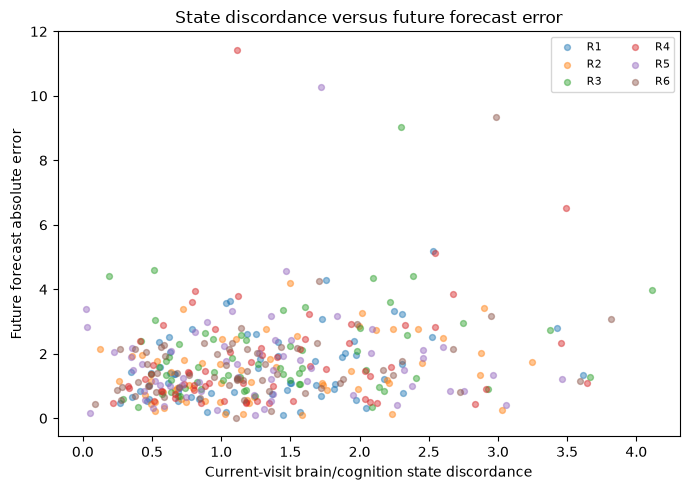

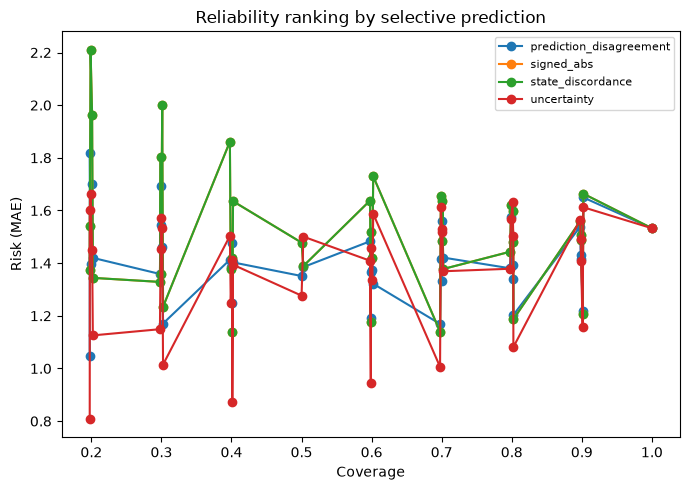

In [64]:
# ============================================================
# 14. PAPER FIGURES
# ============================================================
fig_dir=OUT_ROOT/"figures"
fig_dir.mkdir(exist_ok=True)

# Figure A: subject-level state discordance vs future error, all held-out repeats.
p=test_state.copy()
p=p.groupby(["repeat","subject_id"],as_index=False).agg(
    state_discordance=("state_discordance","mean"),
    abs_error=("abs_error","mean")
)
plt.figure(figsize=(7,5))
for rep,g in p.groupby("repeat"):
    plt.scatter(g["state_discordance"],g["abs_error"],s=18,alpha=.45,label=f"R{rep}")
plt.xlabel("Current-visit brain/cognition state discordance")
plt.ylabel("Future forecast absolute error")
plt.title("State discordance versus future forecast error")
plt.legend(ncol=2,fontsize=8)
plt.tight_layout()
plt.savefig(fig_dir/"state_discordance_vs_error.png",dpi=220)
plt.show()

# Figure B: risk-coverage comparison.
if not selective.empty:
    plt.figure(figsize=(7,5))
    for score,g in selective.groupby("score"):
        g2=g.groupby("coverage",as_index=False)["MAE"].mean()
        plt.plot(g2["coverage"],g2["MAE"],marker="o",label=score)
    plt.xlabel("Coverage")
    plt.ylabel("Risk (MAE)")
    plt.title("Reliability ranking by selective prediction")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(fig_dir/"risk_coverage_comparison.png",dpi=220)
    plt.show()